# Exploration

## Load modules from repo

In [2]:
# Le code suivant dans un notebook permet de :
# - autoriser les imports de fichiers python de ce repo
# - spécifier les chemins relativement à la racine du repo plutôt que relativement au notebook

import os

# Ce code cherche le dossier racine en remontant dans l'arborescence
# jusqu'à ce qu'il trouve le dossier 'src'.
# Cela le rend indépendant de l'endroit où vous lancez le notebook.
try:
    # On part du dossier du notebook
    notebook_dir = os.path.dirname(__file__)
except NameError:
    # __file__ n'existe pas en mode interactif, on utilise le répertoire de travail
    notebook_dir = os.getcwd()

# On remonte jusqu'à trouver un dossier contenant 'src'
project_root = notebook_dir
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent_dir = os.path.dirname(project_root)
    if parent_dir == project_root: # On a atteint la racine du système
        raise FileNotFoundError("Impossible de trouver le dossier 'src'. Vérifiez la structure du projet.")
    project_root = parent_dir

os.chdir(project_root)

In [3]:
os.getcwd()

'/home/val/Documents/Dev/DataScientest/Rakuten'

In [4]:
import src

In [5]:
from src.preprocessing.core import load_extended_df, parallel_feature_creation, split_and_save_dataframe, load_reproducible_split
from src.preprocessing.image import load_image, get_image_features_with_hash, get_image_md5_hash

In [6]:
import importlib
importlib.reload(src.preprocessing.core)
importlib.reload(src.preprocessing.image)

<module 'src.preprocessing.image' from '/home/val/Documents/Dev/DataScientest/Rakuten/src/preprocessing/image.py'>

## Variable cible

In [7]:
import pandas as pd

In [8]:
y = pd.read_csv('Dataset/Y_train.csv',index_col=0)
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [9]:
if not y.index.is_unique:
    print("Warning: Duplicate indices found!")

In [10]:
y2 = pd.read_csv('Dataset/Y_train.csv')
pd.Series(y.index == y2.index).unique(), y2.index

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

L'index de y venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

In [11]:
y2 = pd.read_csv('Dataset/Y_train.csv',index_col=0,dtype='str')

In [12]:
y2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  object
dtypes: object(1)
memory usage: 1.3+ MB


In [13]:
y2.nunique()

prdtypecode    27
dtype: int64

In [14]:
y.nunique()

prdtypecode    27
dtype: int64

La variable cible est de type int et n'a pas besoin d'être chargée en type str, car ça n'induit pas ici de doublons. (Un doublon aurait pu par exemple venir d'un code commençant par un zéro dans le CSV, ce zéro disparaissant lors de la conversion en int.)

In [15]:
del y2

Le graphique de Jessy montre en fait tous les codes produits, pas une liste abrégée ! Le préciser dans le rendu.

In [16]:
y.prdtypecode.unique()

array([  10, 2280,   50, 1280, 2705, 2522, 2582, 1560, 1281, 1920, 2403,
       1140, 2583, 1180, 1300, 2462, 1160, 2060,   40,   60, 1320, 1302,
       2220, 2905, 2585, 1940, 1301])

In [17]:
y.head(15)

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
5,2280
6,10
7,2522
8,1280
9,2582


In [18]:
y.describe()

,prdtypecode
count,84916.000000
mean,1773.219900
std,788.179885
min,10.000000
25%,1281.000000
50%,1920.000000
75%,2522.000000
max,2905.000000


In [19]:
y.value_counts()

prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64

In [20]:
v=y.value_counts(normalize=True).tolist()
v

[0.12022469263742994,
 0.05974139149276932,
 0.05941165386970653,
 0.058799283998304204,
 0.05875217862358095,
 0.057350793725564085,
 0.05622026473220595,
 0.05605539592067455,
 0.05067360685854256,
 0.04655188657025767,
 0.03816712986951811,
 0.03669508690941636,
 0.0325144849027274,
 0.031454613971454146,
 0.030488953789627397,
 0.029535069951481464,
 0.029393753827311696,
 0.029334872108907627,
 0.02437703141928494,
 0.0197960337274483,
 0.016734184370436667,
 0.010268971689669792,
 0.009797917942437232,
 0.00970370719299072,
 0.009503509350416883,
 0.009456403975693627,
 0.008997126572141882]

In [21]:
import numpy as np
ratios = [v[k]/v[-1] for k in range(len(v))]
max(ratios),np.median(ratios),np.std(ratios) #,np.mean(ratios)-np.std(ratios),np.mean(ratios)+np.std(ratios)

(13.362565445026178,
 np.float64(3.4960732984293195),
 np.float64(2.7014821668350457))

Comme l'indique le graphique de Jessy, les catégories sont déséquilibrées : la plupart des catégories sont 3 à 13 fois plus représentées que la plus rare. Les rééquilibrer pourrait améliorer la performance.

## Variables d'entrée

In [22]:
X = pd.read_csv('Dataset/X_train.csv',index_col=0)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB


In [23]:
if not X.index.is_unique:
    print("Warning: Duplicate indices found!")

In [24]:
X2 = pd.read_csv('Dataset/X_train.csv')
pd.Series(X.index == X2.index).unique(), X2.index
# L'index de X venant de index_col=0 est normal, donc pas de précaution particulière à prendre à ce sujet.

(array([ True]), RangeIndex(start=0, stop=84916, step=1))

In [25]:
del X2

In [26]:
X.iloc[:,0].apply(type).unique()

array([<class 'str'>], dtype=object)

In [27]:
X.iloc[:,1].dropna().apply(type).unique()

array([<class 'str'>], dtype=object)

In [28]:
X.head(30)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
5,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830
6,Christof E: Bildungsprozessen Auf Der Spur,NaN,91920807,907794536
7,Conquérant Sept Cahier Couverture Polypro 240 ...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,344240059,999581347
8,Puzzle Scooby-Doo Avec Poster 2x35 Pieces,NaN,4239126071,1325918866
9,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...,3793572222,1245644185


Les variables imageid et productid semblent inutiles pour la prédiction, et servir juste à associer l'image correspondante lors du preprocessing. Il y a donc essentiellement 3 variables a priori : designation, description, image. Ce petit nombre de variables est une difficulté. En revanche, ces variables semblent avoir un contenu riche et complexe, ce qui offre un potentiel fort si on parvient à les exploiter.

In [29]:
# L'ID est sans doublon, pas de problème.
X.productid.nunique()

84916

In [30]:
# L'ID est sans doublon, pas de problème.
X.imageid.nunique()

84916

### Join

In [31]:
# Join on indexes, according to the documentation of the dataset.
df = X.join(y)
df

,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705
...,...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734,40
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883,2583
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617,2280
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403,1560


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


### Variables IDs

Les variables productid et imageid sont de type int et n'ont pas besoin d'être chargées en type str, car elles sont déjà sans doublons. (Un doublon aurait pu par exemple venir d'un ID commençant par un zéro dans le CSV, ce zéro disparaissant lors de la conversion en int.)

In [33]:
df.productid.nunique()

84916

In [34]:
df.imageid.nunique()

84916

### Variables textuelles

La variable designation a 3,1% de doublons (2651).

In [35]:
1-X.designation.nunique()/X.shape[0]

0.031219087097837828

In [36]:
X.shape[0] - X.designation.nunique(),X.designation.nunique()

(2651, 82265)

Hormis les NA, la variable description a 13,8% de doublons (7610 sur 55116).

In [37]:
1 - X.description.dropna().nunique() / X.description.dropna().shape[0], X.description.dropna().shape[0] - X.description.dropna().nunique(), X.description.dropna().shape[0], X.description.dropna().nunique()

(0.13807242905871253, 7610, 55116, 47506)

Les textes sont en au moins 3 langues (allemand, français, anglais), ce qui peut compliquer le NLP. Rakuten étant une entreprise mondiale, on peut s'attendre à ce que bien plus que 3 langues soient représentées dans le jeu de données. Mais le français semble majoritaire.

In [38]:
print('\n#\n'.join(X.designation.iloc[:100]))

Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design
#
Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris - Jacques Barrere - Francois Perrier - La Reforme Des Ventes Aux Encheres Publiques - Le Sna Fete Ses Cent Ans.
#
Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style
#
Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt)
#
La Guerre Des Tuques
#
Afrique Contemporaine N° 212 Hiver 2004 - Dossier Japon / Afrique
#
Christof E: Bildungsprozessen Auf Der Spur
#
Conquérant Sept Cahier Couverture Polypro 240 X 320 Mm 96 Pages 90g Seyès Incolore
#
Puzzle Scooby-Doo Avec Poster 2x35 Pieces
#
Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - Longueur : 4m50 Largeur : 3 M Blanc H
#
Eames Inspired Sxw Chair - Pink - Black
#
Fauteuil Chesterfield Brenton 100% Cuir De Buffle - Vert Empire
#
Peaceable Kingdom Wheres Bear? The Hide And Find Stacking Block Game For 2 Year Olds
#
Paire De 

Beaucoup d'éléments dans les désignations ne sont pas des mots mais peuvent être quand même pertinents pour la prédiction. Nettoyer les désignations sans nuire à la qualité des prédictions peut être délicat. De nombreuses désignations semblent confuses, difficiles à catégoriser même par un humain.

In [39]:
print('\n#\n'.join(X.dropna().description.iloc[:15]))

PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale sur le GamePad de la Wii U: ce grand stylet hautement ergonomique est non seulement parfaitement adapté à votre main mais aussi très élégant.<br> Il est livré avec un support qui se fixe sans adhésif à l'arrière du GamePad<br> <br> Caractéristiques:<br> Modèle: Speedlink PILOT STYLE Touch Pen<br> Couleur: Bleu<br> Ref. Fabricant: SL-3468-BE<br> Compatibilité: GamePad Nintendo Wii U<br> Forme particulièrement ergonomique excellente tenue en main<br> Pointe à revêtement longue durée conçue pour ne pas abîmer l'écran tactile<br> En bonus : Support inclu pour GamePad<br> <span class="vga_style2"><b></b><br>
#
Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'arranger pour en &ecirc;tre le vainqueur incontest&eacute;. Mais Sophie s'en m&ecirc;le et chambarde tous ses plans...
#
CONQUERANT CLASSIQUE 

Les descriptions aussi sont confuses et parsemées de parasites variés. Leurs tailles sont très variables. L'absence de description pour 35% des données représente aussi une difficulté.

In [40]:
df['len_designation']=X.designation.apply(len)

In [41]:
# Les descriptions non NA sont toutes différentes de la chaîne vide '', donc on n'introduit pas d'ambiguïté avec fillna('').
df['len_description']=X.description.fillna('').apply(len)

In [42]:
#done by Jimmy: histogram
# Designation lengths (character counts)
df['len_designation'].describe()

count    84916.000000
mean        70.163303
std         36.793383
min         11.000000
25%         43.000000
50%         64.000000
75%         90.000000
max        250.000000
Name: len_designation, dtype: float64

In [43]:
# description lengths (character counts) (*except* for missing descriptions)
X.description.dropna().apply(len).describe()

count    55116.000000
mean       808.171692
std        805.462153
min          1.000000
25%        259.000000
50%        626.000000
75%       1034.000000
max      12451.000000
Name: description, dtype: float64

In [44]:
# description lengths (character counts) (*including* missing descriptions)
df['len_description'].describe()

count    84916.000000
mean       524.555926
std        754.893905
min          0.000000
25%          0.000000
50%        231.000000
75%        823.000000
max      12451.000000
Name: len_description, dtype: float64

70 descriptions font moins de 5 caractères et semblent presque toutes inutiles à la prédiction. Heureusement, elles ne représentent que 0,1% du jeu de données.

In [45]:
# Taille, Nombre de descriptions de cette taille
v=X.description.dropna().apply(len)[X.description.dropna().apply(len) <= 5].value_counts().sort_index()
v

description
1    28
2     9
3    14
4    19
5     7
Name: count, dtype: int64

In [46]:
# Descriptions de moins de 5 caractères
X.description.dropna()[X.description.dropna().apply(len) <= 5].unique()

array(['50PV.', '1989', '...', 'promo', '-', '0', '1985', '1984', 'nc',
       '.', 'Batty', '(1', 'p', 'jeu', '1972.', '&gt;', '1980', 'Buste',
       'Noir', '1969', 'aa', 'Gris', 'B1962', '3323', '1988', '1947',
       '1986', '1991', '1992', '--', '1996', 'table'], dtype=object)

In [47]:
# Nombre et pourcentage de ces descriptions
v.sum(),v.sum()/X.description.dropna().shape[0]

(np.int64(77), np.float64(0.0013970534871906525))

À partir de 6 caractères, les descriptions commencent à sembler utiles à la prédiction : par exemple, "Roman", "Chevet", "Proust".

In [48]:
# Descriptions de 6 caractères
X.description.dropna()[X.description.dropna().apply(len) == 6].unique()

array(['<br />', 'doudou', 'Notice', 'Roman.', 'argent', 'F.215.',
       'Proust', 'Marron', '18X7cm', 'Chevet'], dtype=object)

In [49]:
# Descriptions de 7 caractères
X.description.dropna()[X.description.dropna().apply(len) == 7].unique()

array(['Piano -', '34x29cm', '2259.00', 'Mensuel', '...<br>', 'Commode',
       'RoHS CE', 'Poupon '], dtype=object)

#### Mots les plus fréquents

##### Variable : description

In [50]:
text = ' '.join(X.description.dropna().str.lower())
text[:100]

'pilot style touch pen de marque speedlink est 1 stylet ergonomique pour gamepad nintendo wii u.<br> '

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

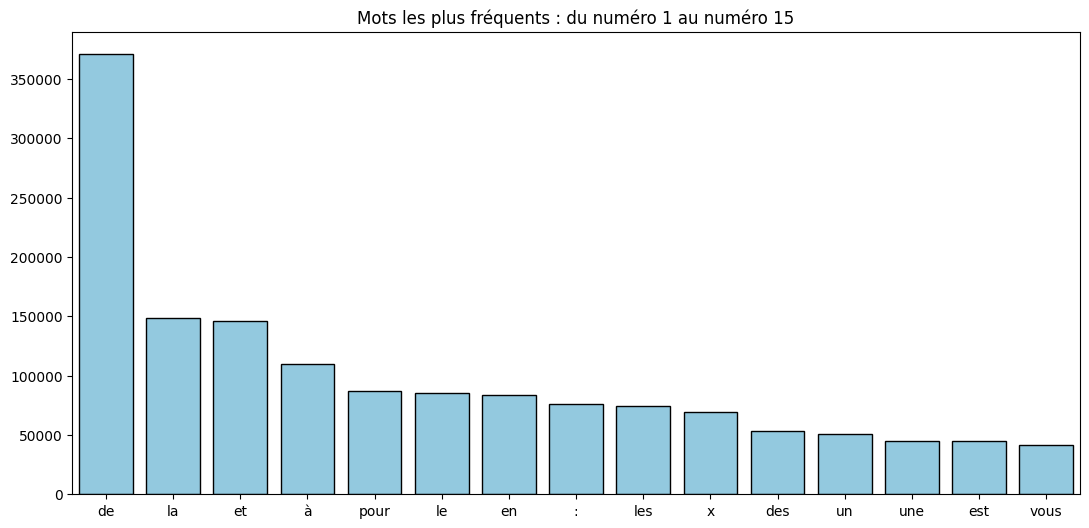

In [51]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [52]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | la | et | à | pour | le | en | : | les | x | des | un | une | est | vous | avec | du | - | /> | votre | 1 | / | <br | dans | ou | sur | pas | cm | plus | peut | il | que | au | ne | haute | par | couleur | a | piscine | être | 2 | * | ce | sont | qualité | qui | the | tout | facile | taille'

In [53]:
# Initialiser la variable des mots vides
stop_words = set('p br li ul cm mm X A b H div'.split())
stop_words |= set(mots)
print(stop_words)

{'*', 'x', 'qui', 'ou', 'X', 'la', 'peut', 'avec', 'le', 'p', 'vous', 'des', 'une', 'que', 'un', 'li', 'les', '/>', 'par', 'mm', 'sont', 'the', 'votre', 'à', 'ul', 'div', 'ce', '-', 'haute', 'pour', '2', 'a', 'A', 'du', 'couleur', 'taille', 'br', 'sur', 'cm', 'plus', 'pas', '/', 'H', 'b', 'dans', 'et', ':', 'ne', 'de', 'piscine', 'est', '1', '<br', 'en', 'au', 'être', 'il', 'tout', 'qualité', 'facile'}


In [54]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'and | /><br | taille: | sans | 3 | plaît | matériel: | dimensions | aux | se | comme | 4 | vos | s&#39;il | enfants | 100% | acier | très | bois | &#43; | l&#39;eau | lumière | cette | to | raison | son | produit | />- | neuf | of | décoration | forfait | non | caractéristiques: | temps | jeu | taie | protection | mode | couleur: | d&#39;un | mesure | batterie | d&#39;une | pouvez | type | main | coussin | (l | 6 | mm | tous | 5 | filtration | l | sac | led | &amp; | sa | bébé | comprend: | contenu | avant | d&#39;eau | design | utiliser | for | pompe | maison | ans | plastique | 1x | hauteur | permettre | couleurs | différence | si | 10 | marque | 1pc | nous | fait | rc | paquet | parfait | elle | surface | durable | ! | blanc | ? | poids | //// | style | m? | forme | d&#39;oreiller | peuvent | cadeau | grande | :</strong> | ces | tissu | couverture | permet | sécurité | également | structure | faire | grand | grâce | facilement | longueur | 8 | voiture | utilisé | </p> | système | m

##### Variable : designation

In [55]:
text = ' '.join(X.designation.str.lower())
text[:100]

'olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design journal des'

Text(0.5, 1.0, 'Mots les plus fréquents : du numéro 1 au numéro 15')

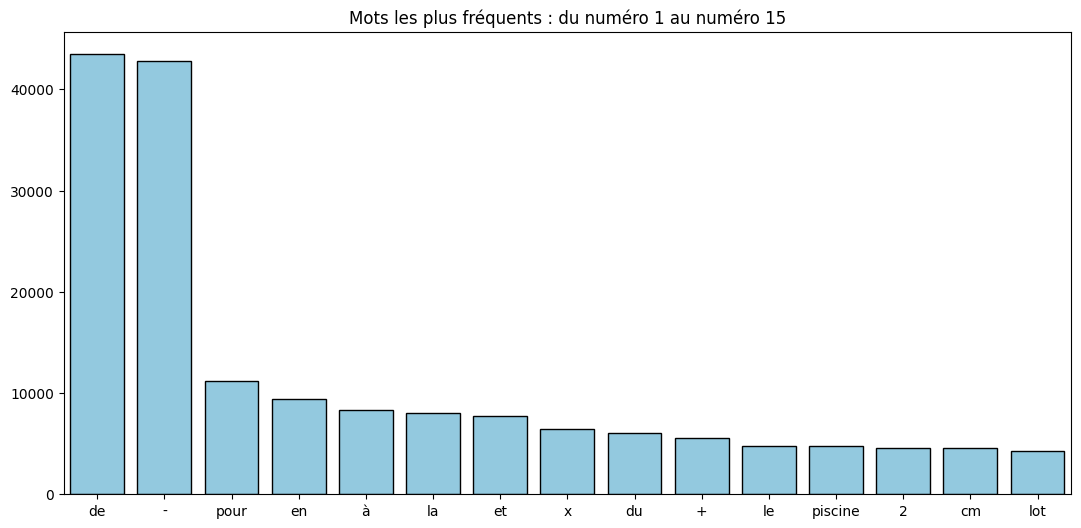

In [56]:
from collections import Counter
import seaborn as sns

dico = Counter(text.split())
first=0
amount=15
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
freq = [m[1] for m in dico.most_common(first+amount)[first:]]

plt.figure(figsize= (13,6))
sns.barplot(x=mots, y=freq, color='skyblue', edgecolor='black')
plt.title(f'Mots les plus fréquents : du numéro {first+1} au numéro {first+amount}')

In [57]:
first=0
amount=50
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'de | - | pour | en | à | la | et | x | du | + | le | piscine | 2 | cm | lot | n° | les | jeu | avec | coussin | : | des | 3 | / | 1 | m | kit | 4 | rc | taie | enfants | blanc | a | bois | led | the | décor | noël | home | & | bébé | décoration | sac | noir | jeux | bâche | bleu | drone | 5 | par'

In [58]:
first=50
amount=300
mots = [m[0] for m in dico.most_common(first+amount)[first:]]
' | '.join(mots)

'of | carte | mini | 6 | couverture | journal | portable | d\'oreiller | dji | acier | jouet | sur | console | mm | lampe | au | cadeau | magideal | voiture | cuisine | 10 | jardin | set | jouets | gris | spa | table | canapé | figurine | housse | pompe | carnet | coton | tapis | toy | classique | bulles | bricolage | tissu | for | support | case | ronde | rouge | maison | douche | téléchargement | 8 | peinture | vert | protection | cover | notes | intex | collection | un | 3d | 12 | super | rose | filtre | livres | quadcopter | peluche | 7 | bain | couleur | salle | bloc-notes | l | lit | stream | gonflable | oreiller | car | sans | pièces | modèle | nintendo | cahier | lumière | solaire | enfant | matelas | sofa | pro | bureau | métal | taille | edition | accueil | france | caméra | throw | papier | plastique | and | silicone | poche | rangement | 20 | pouces | pvc | accessoires | double | mode | fpv | places | tome | (le) | batterie | mavic | star | decor | magic | chaise | | | dans

#### Wordclouds

##### Initialisation

In [59]:
# Complète l'installation de nltk. Utile seulement une fois par PC.
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/val/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
from nltk.corpus import stopwords
stop_words |= set(stopwords.words('french'))
print(stop_words)

{'serons', 'sommes', 'seront', '*', 'eusse', 's', 'êtes', 'soit', 'soyons', 'un', 'mm', 'eût', 'fussions', 'ce', 'eurent', 'haute', '2', 'étée', 'A', 'seriez', 'ayez', 'qualité', 'eûmes', 'br', 'aurai', 'sera', 't', 'H', 'me', 'vos', 'avons', 'eues', 'aies', 'fûtes', 'est', 'ont', 'été', 'au', 'être', 'son', 'aurons', 'aie', 'il', 'étions', 'mais', 'eux', 'c', 'lui', 'qui', 'qu', 'aura', 'auriez', 'seras', 'ayantes', 'auront', 'aurais', 'ayons', 'étants', 'as', 'aurait', 'vous', 'ton', 'n', 'the', 'sont', 'eue', 'eu', 'eussions', 'serai', 'nos', 'à', 'ma', 'ul', 'eussiez', 'fusse', 'pour', 'serais', 'du', 'ta', 'sur', 'notre', 'cm', 'pas', 'sa', 'elle', 'es', 'leur', 'b', ':', 'serions', 'ayante', 'on', 'était', 'ses', 'étais', 'étant', 'moi', 'eussent', 'x', 'avaient', 'étaient', 'soyez', 'fût', 'X', 'fussent', 'y', 'peut', 'avec', 'étés', 'étiez', 'p', 'eus', 'des', 'une', 'par', 'li', '/>', 'm', 'eûtes', 'même', 'div', '-', 'ai', 'aurez', 'avait', 'ayant', 'plus', 'étantes', '/', 'i

In [61]:
# Mieux sans masque
mask_coloring = None

In [62]:
# from PIL import Image
# path = 'images/mask.png'
# mask_coloring = np.array(Image.open(str(path)))

##### Variable : designation

In [63]:
import wordcloud
from wordcloud import WordCloud
wc1 = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [64]:
text = ' '.join(X.designation)
wc1.generate(text)
len(text)

6042902

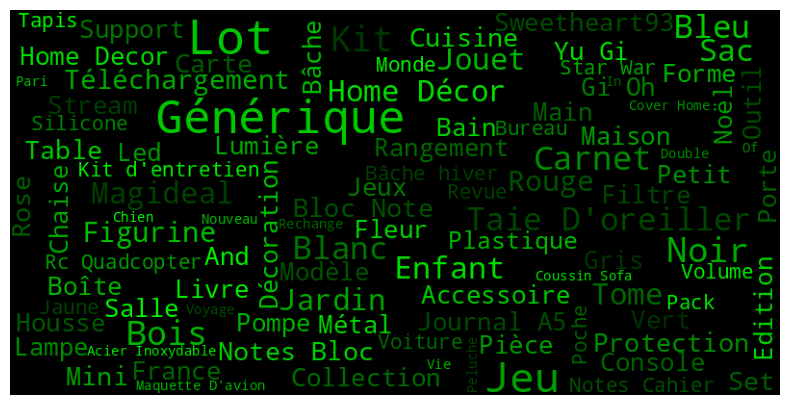

In [65]:
import matplotlib.pyplot as plt

# Générer et afficher le nuage de mots

plt.figure(figsize=(13,5))
plt.imshow(wc1)
plt.axis('off')
plt.show()

Le français semble largement majoritaire, suivi par l'anglais.

##### Variable : description

(Cellules commentées car elles mettent du temps à charger.)

In [66]:
# wc = WordCloud(width=800, height=400, background_color="black", color_func = wordcloud.get_single_color_func('green'), mask = mask_coloring, max_words=100, max_font_size=50, stopwords=stop_words, random_state=42)

In [67]:
# text = ' '.join(X.description.dropna())
# len(text)

In [68]:
# # Dure 12s.
# wc.generate(text)

In [69]:
# plt.figure(figsize=(13,5))
# plt.imshow(wc)
# plt.axis('off')
# plt.show()

### Images

In [70]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

#### Display

In [71]:
def display_images(rows,nrow,ncol,axis=False,color=True):
    n = len(rows)
    if n > nrow*ncol:
        print('(`rows` is too long for this grid. Not showing all images.)')
        n = nrow*ncol
    plt.figure(figsize=(13,8))
    for k in range(n):
        plt.subplot(nrow,ncol,k+1)
        row = rows.iloc[k]
        if color:
            image_bgr = load_image(row, color=color)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            plt.imshow(image_rgb)
        else:
            plt.imshow(load_image(row,color=color), cmap='gray')
        if axis:
            # Keep boundaries visible but without numbers
            plt.xticks([])
            plt.yticks([])
        else:
            plt.axis('off')

Show random images from the dataset.

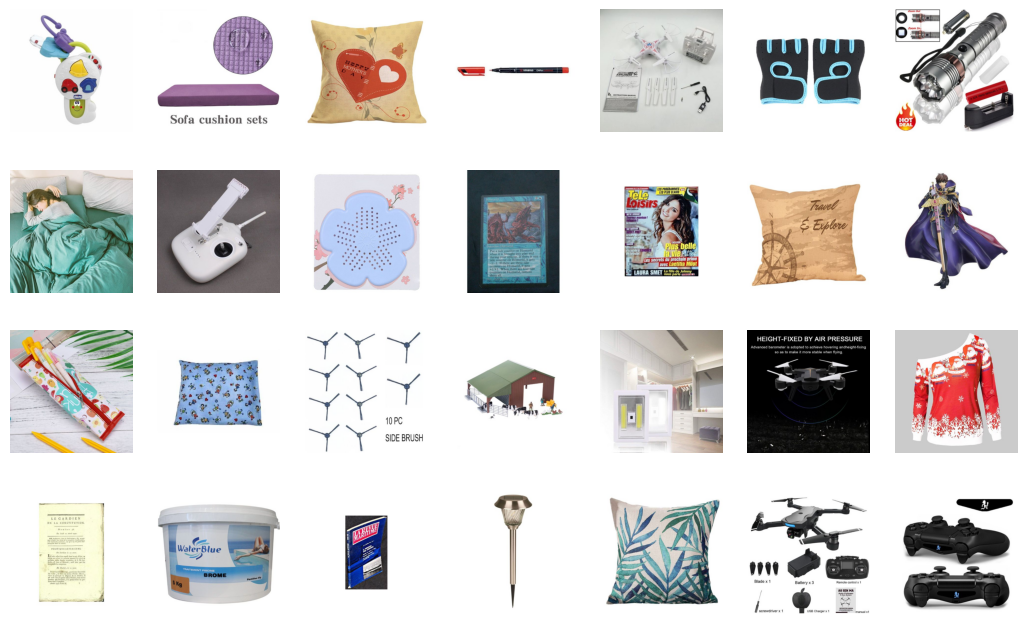

In [72]:
nrow = 4
ncol = 7
n = nrow*ncol
rows = X.sample(n)
display_images(rows,nrow,ncol)

Bien que les images aient le même nombre de pixels, certaines sur fond blanc ont des couleurs sur seulement une petite partie de l'image. On peut envisager de s'intéresser aux pixels non blancs. Certes, certaines images ont un fond différent, mais elles semblent plus rares.

#### Pixel count

In [73]:
def count_pixels(row, folder = 'Dataset/images/image_train'):
    img_color = load_image(row, folder = folder)
    return img_color.shape

On regarde les dimensions d'images aléatoires du jeu de données. (Regarder toutes les images met longtemps à charger.) Elles ont toutes les mêmes dimensions.

In [74]:
X.sample(100).apply(count_pixels,axis=1).unique()

array([(500, 500, 3)], dtype=object)

In [75]:
500*500*3

750000

In [76]:
# # Regarde pour toutes les lignes, donc met 2m30 à charger. Résultat : array([(500, 500, 3)], dtype=object).
# X.apply(count_pixels,axis=1).unique()

#### Create features

##### Color features

In [77]:
pd.DataFrame(df.sample(3).apply(get_image_features_with_hash,axis=1).tolist())

,image_hash,gray_image_hash,mean_r,mean_g,mean_b,std_r,std_g,std_b,median_r,median_g,median_b,mean_gray,std_gray,median_gray,essential_pixel_count,x_min,y_min,x_max,y_max
0,c174b283b346ce8f,c174b283b346ce8f,104.554264,89.196737,74.091963,76.183571,70.518373,64.479204,87.0,72.0,61.0,92.071472,70.672870,76.0,185639,0,56,499,439
1,a80c0e36b79ce769,a80c0e36b79ce769,123.935740,118.441319,117.975615,77.380471,75.183405,75.279193,102.0,93.0,90.0,120.025690,74.908362,97.0,98133,0,0,499,447
2,b2cc893333ccce33,b2cc893333ccce33,175.560553,135.895744,127.882797,59.325857,59.424413,60.262285,194.0,140.0,125.0,146.845382,56.623470,150.0,16143,192,175,303,327


In [78]:
# # Dure 3m
# features_df=parallel_feature_creation(df, get_image_features_with_hash, verbose=1)

In [79]:
original_cols = ['designation', 'description', 'productid', 'imageid', 'prdtypecode']
original_df = df[original_cols]
original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


In [80]:
# features_df

In [81]:
# features_df.image_pHash.nunique()

In [82]:
# features_df[features_df.image_pHash!=features_df.gray_image_pHash].shape[0]

In [83]:
# base_df=original_df.join(features_df)
# base_df.info()

##### MD5 hash

In [84]:
pd.DataFrame(df.iloc[:3].apply(get_image_md5_hash,axis=1).tolist())

,0
0,9c65f3c9b9e320cec9e6ce2f5ed6b1e8
1,56538c4375792defafb0637bd511fb6f
2,6641107a0882bf7f4739124e2e47de87


In [85]:
# Dure 10s
# df['image_hash_md5']=df.apply(get_image_md5_hash,axis=1)

In [86]:
# # Dure 3s
# features_df=parallel_feature_creation(df, get_image_md5_hash, verbose=1)

In [87]:
# df['image_hash_md5']

In [88]:
# df=df.rename(columns={'image_hash': 'image_pHash','gray_image_hash':'gray_image_pHash'})

In [89]:
# df.info()

#### Save df

In [90]:
# print(df.columns.tolist())

In [91]:
# # These (except `prdtypecode_str`) are quickly recalculated by the function `load_extended_df` to save space.
# cols_to_drop='''len_designation
# len_description
# essential_width
# essential_height
# essential_aspect_ratio
# essential_area
# rectangleness
# prdtypecode_str'''.split()
# cols_to_drop

In [92]:
# # Save to disk.
# df.drop(columns=cols_to_drop).to_parquet('Dataset2/df2.parquet', compression='gzip')

##### Split dataset and save

In [93]:
# train_df, test_df = split_and_save_dataframe(df)

In [94]:
# train_df.info()

In [95]:
# test_df.info()

#### Load extended df

In [96]:
df=load_extended_df(path='Dataset2/df.parquet')
df['prdtypecode_str'] = df['prdtypecode'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             84916 non-null  object 
 1   description             55116 non-null  object 
 2   productid               84916 non-null  int64  
 3   imageid                 84916 non-null  int64  
 4   prdtypecode             84916 non-null  int64  
 5   image_pHash             84916 non-null  object 
 6   gray_image_pHash        84916 non-null  object 
 7   mean_r                  84916 non-null  float64
 8   mean_g                  84916 non-null  float64
 9   mean_b                  84916 non-null  float64
 10  std_r                   84916 non-null  float64
 11  std_g                   84916 non-null  float64
 12  std_b                   84916 non-null  float64
 13  median_r                84916 non-null  float64
 14  median_g                84916 non-null  flo

In [97]:
raise Exception("Permet d'éviter de relancer avec `Run All` les cellules qui durent longtemps.")

Exception: Permet d'éviter de relancer avec `Run All` les cellules qui durent longtemps.

#### Load split

In [ ]:
X_train, X_test, y_train, y_test = load_reproducible_split(folder = 'Dataset2')

#### Word count of text variables

In [ ]:
# Concaténer les deux colonnes
# Le jeton [SEP] est optionnel mais peut aider le deep learning
X_train['full_text'] = X_train['designation'] + ' [SEP] ' + X_train['description'].fillna('')

Statistiques sur la longueur des textes (en mots) :
count    67932.000000
mean        92.472914
std        115.985168
min          4.000000
25%         12.000000
50%         49.000000
75%        138.000000
max       2079.000000
Name: full_text, dtype: float64
------------------------------
Le 95ème percentile est : 303 mots.

Une bonne valeur pour 'output_sequence_length' pourrait être autour de 303 ou une valeur arrondie supérieure.


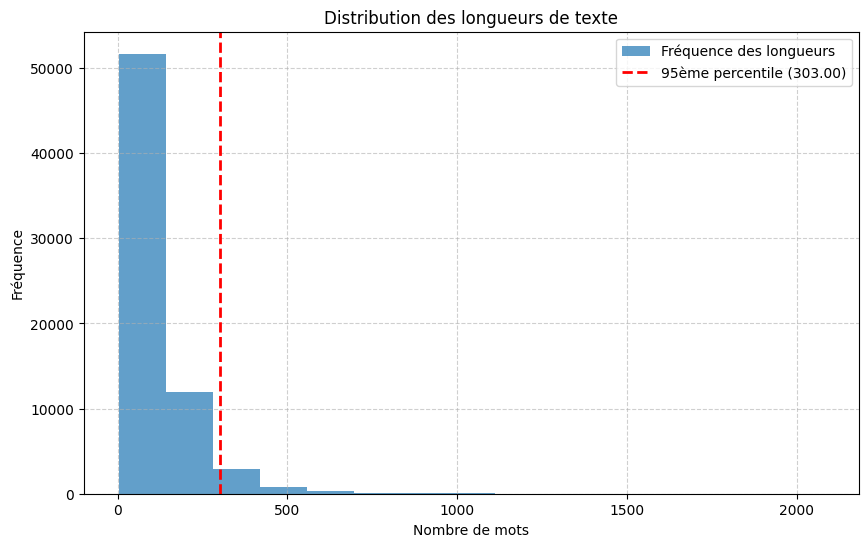

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculer la longueur de chaque texte (en nombre de mots)
# L'expression `str.split().str.len()` divise chaque chaîne par les espaces
# puis compte le nombre d'éléments dans la liste résultante.
longueurs = X_train['full_text'].str.split().str.len()

# 2. Afficher des statistiques descriptives
print("Statistiques sur la longueur des textes (en mots) :")
print(longueurs.describe())
print("-" * 30)

# 3. Calculer les percentiles
# Le 95ème percentile est une valeur commune, mais vous pouvez tester d'autres valeurs (98, 99).
percentile_95 = int(np.percentile(longueurs, 95))
percentile_98 = int(np.percentile(longueurs, 98))

print(f"Le 95ème percentile est : {percentile_95} mots.")
print("\nUne bonne valeur pour 'output_sequence_length' pourrait être "
      f"autour de {percentile_95} ou une valeur arrondie supérieure.")

# 4. (Optionnel) Visualiser la distribution avec un histogramme
plt.figure(figsize=(10, 6))
plt.hist(longueurs, bins=15, alpha=0.7, label="Fréquence des longueurs")
plt.axvline(
    percentile_95,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f"95ème percentile ({percentile_95:.2f})"
)
plt.title("Distribution des longueurs de texte")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

On choisit alors output_sequence_length=310 pour la TextVectorization pour le deep learning.

#### Images triées par densité (nombre de pixels non blancs)

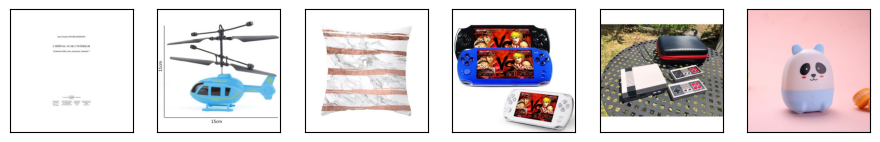

In [ ]:
rows = []
step=0.03
for a in np.linspace(step,1,6):
    new_rows = df[(df.essential_pixel_count < df.essential_pixel_count.quantile(a)) & (df.essential_pixel_count >= df.essential_pixel_count.quantile(a-step))]
    if new_rows.empty:
        print(f"No row for {a=}.")
    else:
        rows.append(new_rows.sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=True)


#### Images selon rectangularité

Mesure à quel point le produit remplit son rectangle délimitant, en supposant que "blanc"="vide" (niveau de gris >= 250).

In [ ]:
# Images à rectangularité faible mais non toutes blanches
rows = df[(df.rectangleness < .06) & (df.rectangleness > 0)]
rows.shape

(33, 32)

(`rows` is too long for this grid. Not showing all images.)


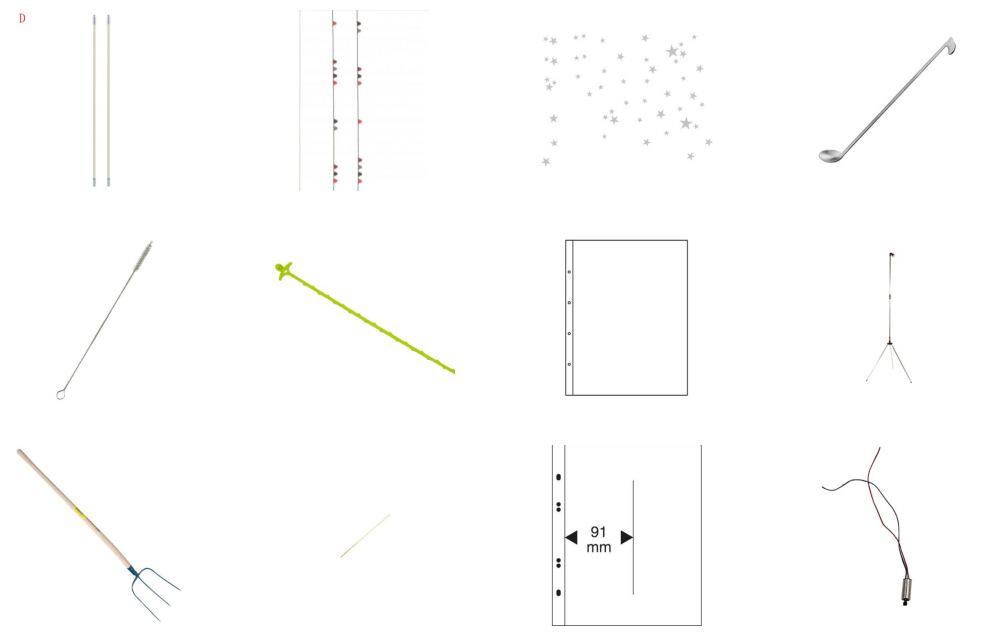

In [ ]:
display_images(rows,3,4)

In [ ]:
# Images à rectangularité moyenne
a=.40
rows = df[(df.rectangleness < a) & (df.rectangleness > a-.01)]
rows.shape

(495, 33)

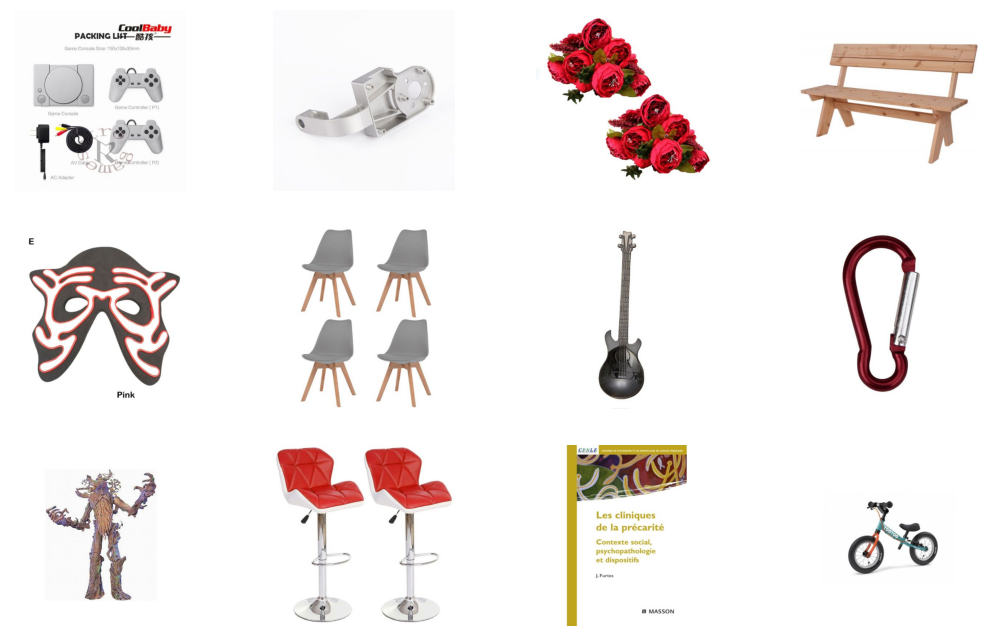

In [ ]:
display_images(rows[:12],3,4,axis=False)

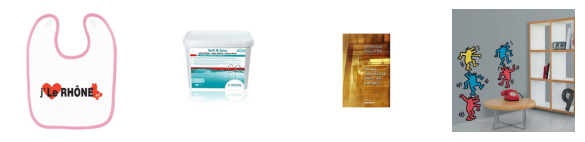

In [ ]:
# De rectangularité faible à haute (à quel point le produit ressemble à un rectangle plein, en supposant que "blanc"="vide")
rows = []
step=0.03
for a in np.linspace(step,1,4):
    new_rows = df[(df.rectangleness < df.rectangleness.quantile(a)) & (df.rectangleness >= df.rectangleness.quantile(a-step))]
    if new_rows.empty:
        print(f"No row for {a=}.")
    else:
        rows.append(new_rows.sample(1))
rows = pd.concat(rows)
display_images(rows,1,7,axis=False)

#### Analyze image features
Nombre de valeurs uniques et type de chaque colonne.

In [ ]:
for col in df.columns[0:]:
    print(f"{col} {df[col].nunique()} {df[col].dtype}")

designation 82265 object
description 47506 object
productid 84916 int64
imageid 84916 int64
prdtypecode 27 int64
image_hash 77326 object
gray_image_hash 77326 object
mean_r 79221 float64
mean_g 79223 float64
mean_b 79223 float64
std_r 79221 float64
std_g 79221 float64
std_b 79221 float64
median_r 336 float64
median_g 329 float64
median_b 336 float64
mean_gray 79223 float64
std_gray 79221 float64
median_gray 323 float64
essential_pixel_count 59887 int64
x_min 242 int64
y_min 253 int64
x_max 248 int64
y_max 257 int64
len_designation 239 int64
len_description 3718 int64
essential_width 482 int64
essential_height 483 int64
essential_aspect_ratio 23770 float64
essential_area 19480 int64
rectangleness 71091 float64
prdtypecode_str 27 object


Les variables essential_area et essential_pixel_count ne semblent pas redondantes : leur ratio rectangleness n'est pas constant.

In [ ]:
df['rectangleness'].describe()

count    84916.000000
mean         0.772658
std          0.234638
min          0.000000
25%          0.601350
50%          0.863722
75%          0.976865
max          1.000000
Name: rectangleness, dtype: float64

In [ ]:
df['essential_pixel_count'].describe()

count     84916.00000
mean     122645.61416
std       67623.08015
min           0.00000
25%       64915.25000
50%      118570.50000
75%      178137.00000
max      250000.00000
Name: essential_pixel_count, dtype: float64

In [ ]:
pd.set_option('display.max_columns', None)

# mean_[rgb] : teinte globale de l'image
# mean_gray : luminosité de l'image
# std_[rgb] : contraste, variété des couleurs
# std_gray : variété de la luminosité
df.loc[:,'mean_r':].describe()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,median_r,median_g,median_b,mean_gray,std_gray,median_gray,essential_pixel_count,x_min,y_min,x_max,y_max,len_designation,len_description,essential_width,essential_height,essential_aspect_ratio,essential_area,rectangleness
count,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.00000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000,84916.000000
mean,143.562132,135.180684,128.925992,57.335443,55.983011,56.535270,145.700316,135.506006,127.747627,136.972031,53.994137,137.150767,122645.61416,55.918555,55.781254,442.835732,446.159605,70.163303,524.555926,387.917177,391.378350,1.103680,155294.573920,0.772658
std,48.792538,45.634395,47.960425,19.309409,17.473904,17.859333,63.658667,59.725152,62.263866,43.941498,16.707802,56.962633,67623.08015,56.063024,55.990220,56.561352,54.738523,36.793383,754.893905,111.668303,108.735001,0.841226,63510.255396,0.234638
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,1.000000,1.000000,0.047500,1.000000,0.000000
25%,108.846342,102.310056,92.766568,44.342063,44.261279,44.528562,96.000000,89.000000,75.000000,105.895809,42.960958,94.000000,64915.25000,0.000000,0.000000,400.750000,407.000000,43.000000,0.000000,308.000000,313.000000,0.736000,115059.500000,0.601350
50%,144.368824,134.386076,126.515568,58.453642,56.685578,57.508859,153.000000,137.000000,125.000000,135.876238,54.529370,137.000000,118570.50000,48.000000,48.000000,454.000000,456.000000,64.000000,231.000000,408.000000,410.000000,1.000000,167000.000000,0.863722
75%,181.099069,169.498926,164.911760,71.355476,68.311430,69.333415,200.000000,185.000000,181.000000,169.654454,65.610135,184.000000,178137.00000,96.000000,96.000000,499.000000,499.000000,90.000000,823.000000,499.000000,500.000000,1.302083,192500.000000,0.976865
max,254.814110,251.942275,253.615896,120.843262,116.416391,119.377007,255.000000,255.000000,255.000000,246.106981,112.415541,249.000000,250000.00000,248.000000,382.000000,499.000000,499.000000,250.000000,12451.000000,500.000000,500.000000,27.055556,250000.000000,1.000000


In [ ]:
pd.reset_option('display.max_columns')

4 images sont toutes blanches.

In [ ]:
rows_with_white_image = df[df.essential_pixel_count == 0]
rows_with_white_image

,designation,description,productid,imageid,prdtypecode,image_hash,gray_image_hash,mean_r,mean_g,mean_b,...,x_max,y_max,len_designation,len_description,essential_width,essential_height,essential_aspect_ratio,essential_area,rectangleness,prdtypecode_str
37124,Römer Britax Kid Ii Cosmos Black - Siège Auto,Römer Britax KID II Cosmos Black - Siège Auto,884747735,1142089742,1320,8000000000000000,8000000000000000,0.0,0.0,0.0,...,0,0,45,45,1,1,1.0,1,0.0,1320
52327,Minions Peluche Electronique 25 Cm - Stuart,MINIONS - Retrouve l&#39;univers drôle et déja...,3793782107,1302249863,1280,8000000000000000,8000000000000000,0.0,0.0,0.0,...,0,0,43,241,1,1,1.0,1,0.0,1280
79708,Blagdon extract of barley straw treatment (siz...,None,1892606336,1137819811,2583,8000000000000000,8000000000000000,0.0,0.0,0.0,...,0,0,57,0,1,1,1.0,1,0.0,2583
80859,Bledina Mini Lactes Nature Sans Sucre - 6 X 55g,BLEDINA Mini lactes nature sans sucre - 6 x 55...,3894592691,1271791205,1940,8000000000000000,8000000000000000,0.0,0.0,0.0,...,0,0,47,279,1,1,1.0,1,0.0,1940


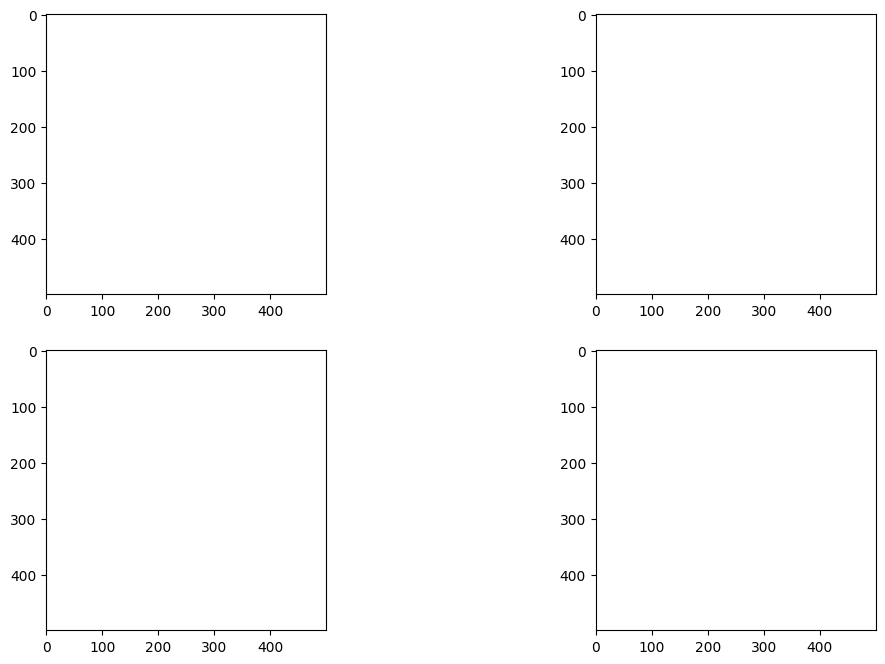

In [ ]:
display_images(rows_with_white_image,2,2,axis=True)

#### Image hashes

##### Gray and color pHashes

Seulement 17 produits (affichés ci-dessous) sur 84 916 ont une image dont le hash en niveaux de gris diffère du hash en couleur. Ceci aurait pu suggérer que la couleur n'est pas "importante" pour le jeu de données, sauf pour ces 17 produits. Mais en réalité, c'est simplement que l'algorithme de hash perceptuel utilisé ignore par conception les couleurs et se concentre sur la structure de l'image. L'exemple le plus parlant est celui de la flèche rouge sur fond vert, qui disparaît quasiment lors de la conversion en nuances de gris.

In [ ]:
diff=df[df.image_pHash != df.gray_image_pHash]
diff.shape[0]

17

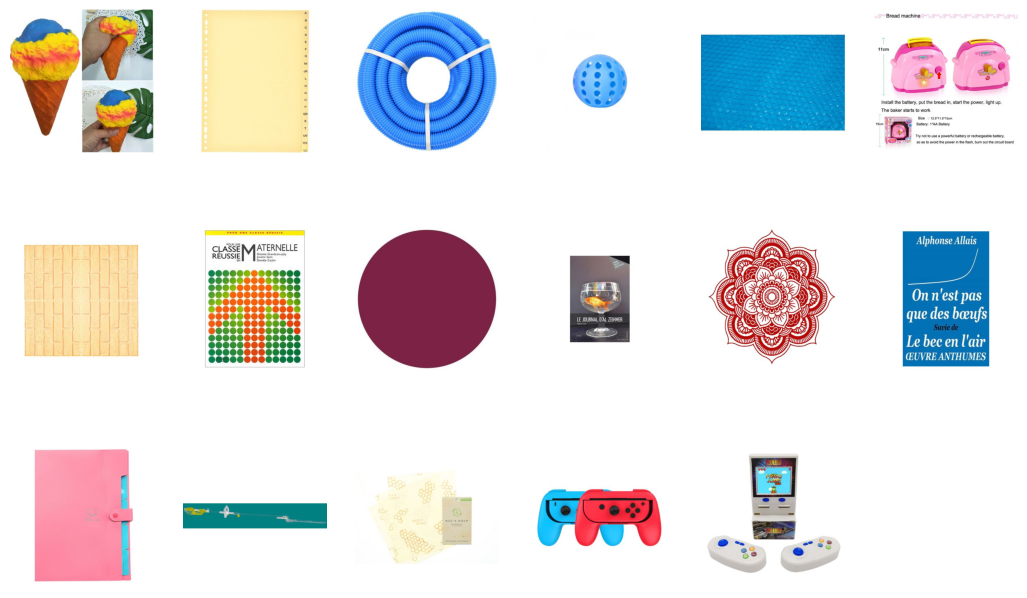

In [ ]:
nrow = 3
ncol = 6
n = nrow*ncol
display_images(diff,nrow,ncol)

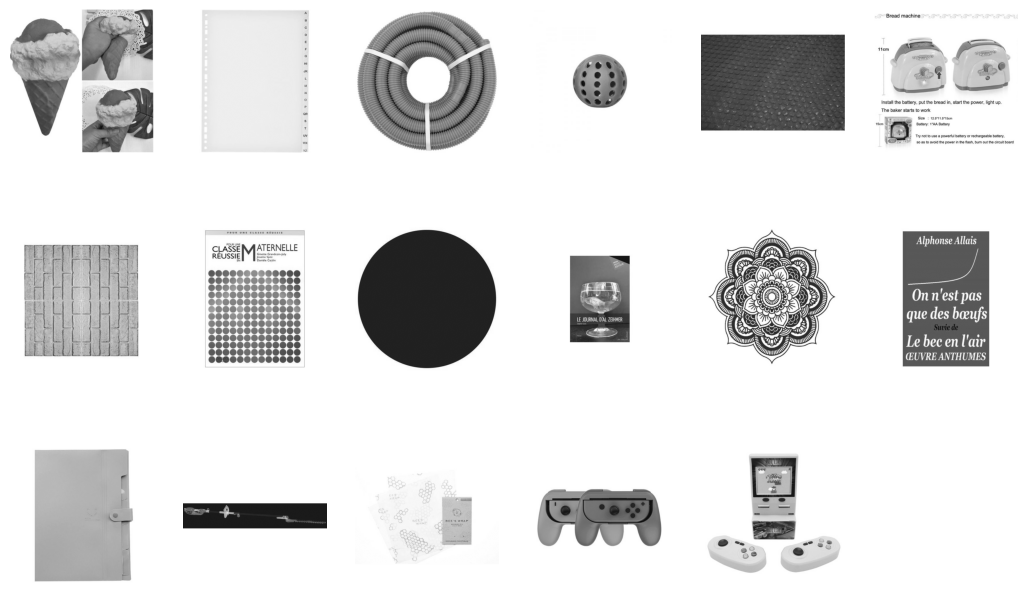

In [ ]:
nrow = 3
ncol = 6
n = nrow*ncol
display_images(diff,nrow,ncol,color=False)

##### Color hash

Il y a 77 326 images uniques pour le hash perceptuel, 79224 pour le hash MD5. Donc 7590 produits (9%) ont des images répétées selon le hash perceptuel, et 5692 (7%) pour le MD5. Que deux produits aient la même image peut fortement suggérer qu'ils aient la même catégorie.

In [ ]:
df.image_pHash.nunique(), df.shape[0] - df.image_pHash.nunique(), (df.shape[0] - df.image_pHash.nunique())/df.shape[0]

(77326, 7590, 0.08938244853737812)

In [100]:
df.image_hash_md5.nunique(), df.shape[0] - df.image_hash_md5.nunique(), (df.shape[0] - df.image_hash_md5.nunique())/df.shape[0]

(79224, 5692, 0.06703094823119318)

In [101]:
# Trouver les images qui sont des doublons
# `keep=False` marque TOUTES les occurrences d'un doublon comme True
duplicates_mask = df.duplicated(subset=['image_pHash'], keep=False)
duplicates_mask_md5 = df.duplicated(subset=['image_hash_md5'], keep=False)

# Afficher les groupes d'images en double, triées par leur hash
print("Images en double détectées :")
df[duplicates_mask].sort_values('image_pHash')

Images en double détectées :


,designation,description,productid,imageid,prdtypecode,image_pHash,gray_image_pHash,mean_r,mean_g,mean_b,...,y_max,image_hash_md5,len_designation,len_description,essential_width,essential_height,essential_aspect_ratio,essential_area,rectangleness,prdtypecode_str
40000,Papier Peint Autocollant Aspect Satine Moutard...,Cet adhesif est ideal pour recouvrir les meub...,3921650416,1263803707,2060,8000000000000000,8000000000000000,191.000000,162.000000,62.000000,...,499,2851c759e4d83d3009a21c6c53bda143,63,1034,500,500,1.000000,250000,1.000000,2060
79708,Blagdon extract of barley straw treatment (siz...,None,1892606336,1137819811,2583,8000000000000000,8000000000000000,0.000000,0.000000,0.000000,...,0,045f0aa4f855da280cd0dbac4f4383c7,57,0,1,1,1.000000,1,0.000000,2583
29955,Papier Peint Autocollant Aspect Satine Vert Ne...,Cet adhesif est ideal pour recouvrir les meub...,3921649686,1263803373,2060,8000000000000000,8000000000000000,176.000000,215.000000,136.000000,...,499,9f487c58c42a7a50ade3b8615886d5f7,67,1034,500,500,1.000000,250000,1.000000,2060
80859,Bledina Mini Lactes Nature Sans Sucre - 6 X 55g,BLEDINA Mini lactes nature sans sucre - 6 x 55...,3894592691,1271791205,1940,8000000000000000,8000000000000000,0.000000,0.000000,0.000000,...,0,045f0aa4f855da280cd0dbac4f4383c7,47,279,1,1,1.000000,1,0.000000,1940
52327,Minions Peluche Electronique 25 Cm - Stuart,MINIONS - Retrouve l&#39;univers drôle et déja...,3793782107,1302249863,1280,8000000000000000,8000000000000000,0.000000,0.000000,0.000000,...,0,045f0aa4f855da280cd0dbac4f4383c7,43,241,1,1,1.000000,1,0.000000,1280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42889,Sauna traditionnel Lumios - 220 x 200 x 210 - ...,Dimensions : 220x200x210 cm ou 200x200x210 cm ...,554019770,1025671259,2583,ffd990848166d06f,ffd990848166d06f,143.533381,116.569955,99.936264,...,463,6cdddad0d76f78c9e39103950be348a5,57,745,463,415,1.115663,192145,0.926795,2583
14477,Sauna traditionnel Lumios - 200 x 200 x 210 - ...,Dimensions : 220x200x210 cm ou 200x200x210 cm ...,554019767,1025671262,2583,ffd990848166d06f,ffd990848166d06f,143.533381,116.569955,99.936264,...,463,6cdddad0d76f78c9e39103950be348a5,57,745,463,415,1.115663,192145,0.926795,2583
14269,Serre De Jardin En Verre Trempé Royal 38 - 182...,Le modèle de <strong>serre Royal 38</strong> c...,3773730519,1243393545,2582,fffef8708481844a,fffef8708481844a,96.218413,117.618203,89.269396,...,471,4673347bc6ab98aff4de4b112e73befb,97,1553,472,440,1.072727,207680,0.951059,2582
42528,Serre De Jardin En Verre Trempé Royal 38 - 182...,Le modèle de <strong>serre Royal 38</strong> c...,3773730564,1243393767,2582,fffef8708481844a,fffef8708481844a,96.218413,117.618203,89.269396,...,471,4673347bc6ab98aff4de4b112e73befb,95,1553,472,440,1.072727,207680,0.951059,2582


Les images répétées figurent parmi 3202 images uniques. On en affiche aléatoirement quelques unes ci-dessous. Des piscines sont souvent représentées.

In [102]:
df[duplicates_mask].image_pHash.nunique(), df[duplicates_mask_md5].image_pHash.nunique()

(3927, 3202)

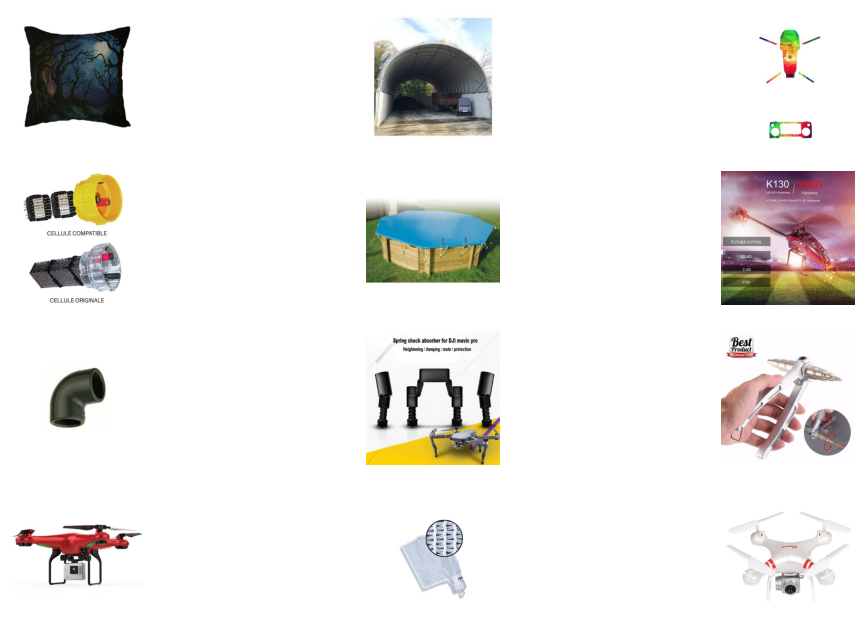

In [104]:
#MD5
import random
rows=[]
hashes = df[duplicates_mask_md5].image_hash_md5.unique().tolist()
for hash in random.sample(hashes, 12):
    rows.append(df[df.image_hash_md5 == hash].sample(1))
rows = pd.concat(rows)
display_images(rows,nrow=4,ncol=3)

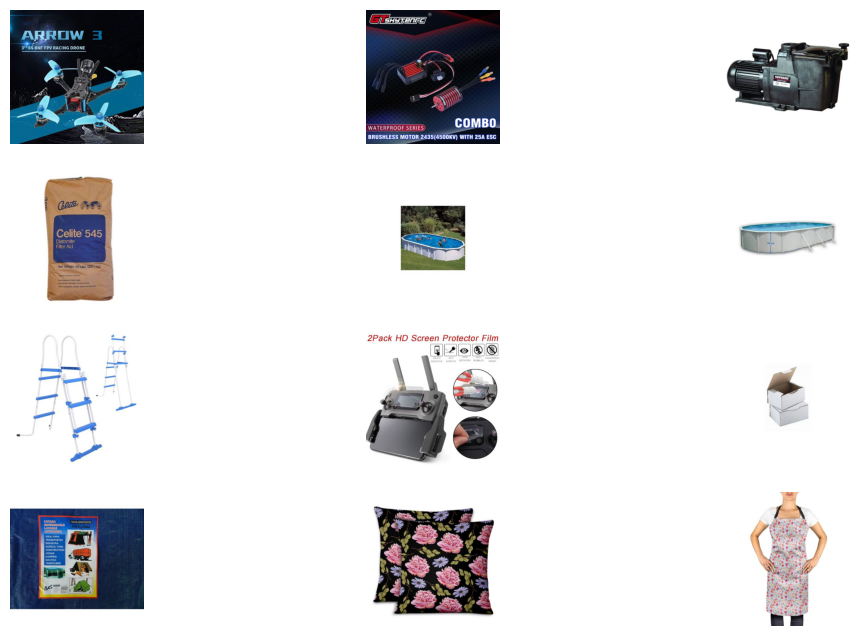

In [ ]:
#pHash
import random
rows=[]
hashes = df[duplicates_mask].image_pHash.unique().tolist()
for hash in random.sample(hashes, 12):
    rows.append(df[df.image_pHash == hash].sample(1))
rows = pd.concat(rows)
display_images(rows,nrow=4,ncol=3)

Ci-dessous, on vérifie sur des exemples aléatoires que le pHash est un bon moyen de trouver des images quasiment identiques. On ignore la qualité du rappel mais la précision est assez bonne, quoique j'ai trouvé une fois une collision : des images assez différentes (deux livres de taille similaire) avec un même hash.

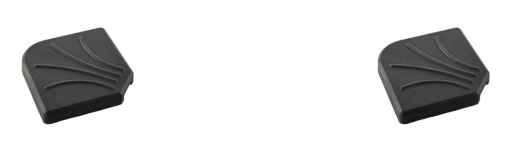

In [ ]:
import random
rows=[]
hashes = df[duplicates_mask].image_pHash.unique().tolist()
hash = random.sample(hashes, 1)[0]
rows = df[df.image_pHash == hash]
display_images(rows,nrow=4,ncol=3)

In [ ]:
# rows = df[df.image_pHash == '']
# display_images(rows,nrow=4,ncol=3)

##### Histogramme des MD5 répétés

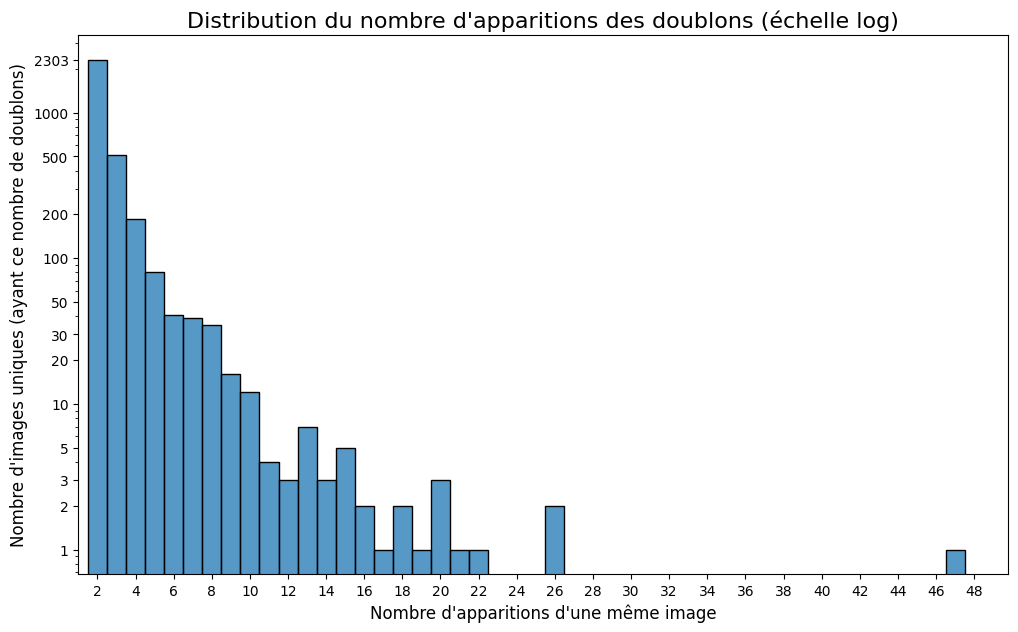

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter

# 1. Calculer le nombre d'apparitions de chaque hash
image_counts = df['image_hash_md5'].value_counts()

# 2. Isoler les comptes des images qui apparaissent plus d'une fois
duplicate_counts = image_counts[image_counts > 1]

# 3. Créer l'histogramme de ces comptes
plt.figure(figsize=(12, 7))
ax=sns.histplot(data=duplicate_counts, discrete=True)
ax.set_yscale('log')
max_y_value = duplicate_counts.value_counts().max()
y_ticks = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 500, 1000, max_y_value, 5000]
y_ticks_filtered = [tick for tick in y_ticks if tick <= max_y_value]
ax.set_yticks(y_ticks_filtered)
ax.yaxis.set_major_formatter(ScalarFormatter())

# Définir le localisateur pour afficher une graduation tous les 2 pas
ax.xaxis.set_major_locator(MultipleLocator(2))
# Pour un pas de 1, utiliser : ax.xaxis.set_major_locator(MultipleLocator(1))

# Pivoter les labels
# plt.xticks(rotation=45)

plt.title("Distribution du nombre d'apparitions des doublons (échelle log)", fontsize=16)
plt.xlim(left=1)
plt.xlabel("Nombre d'apparitions d'une même image", fontsize=12)
plt.ylabel("Nombre d'images uniques (ayant ce nombre de doublons)", fontsize=12)
plt.show()

In [ ]:
df.prdtypecode.value_counts()

prdtypecode
2583    10209
1560     5073
1300     5045
2060     4993
2522     4989
1280     4870
2403     4774
2280     4760
1920     4303
1160     3953
1320     3241
10       3116
2705     2761
1140     2671
2582     2589
40       2508
2585     2496
1302     2491
1281     2070
50       1681
2462     1421
2905      872
60        832
2220      824
1301      807
1940      803
1180      764
Name: count, dtype: int64

##### Histogramme des color pHashes répétés

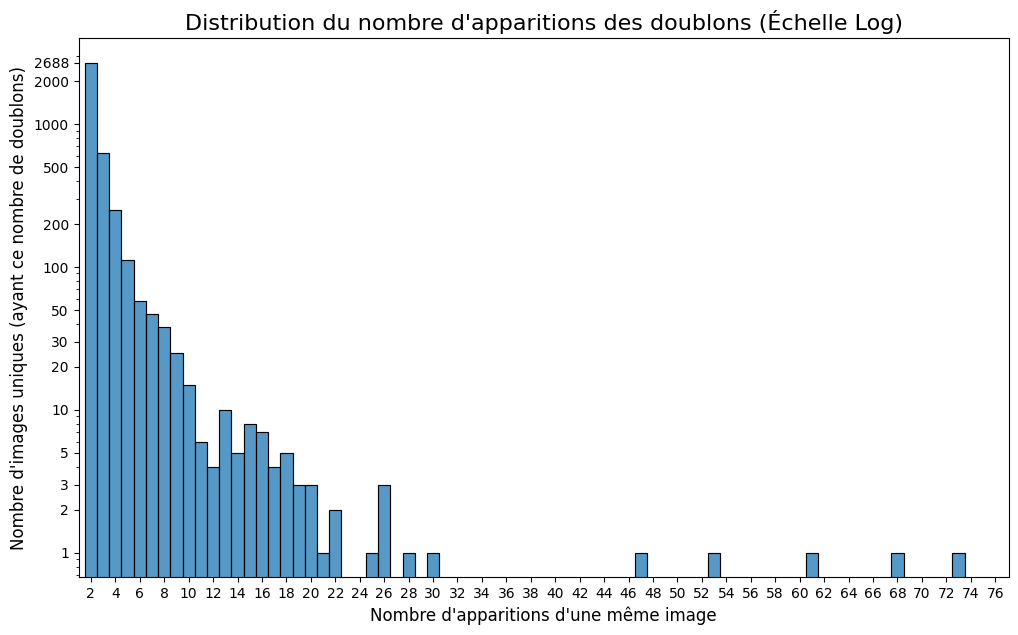

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter

# 1. Calculer le nombre d'apparitions de chaque hash
image_counts = df['image_pHash'].value_counts()

# 2. Isoler les comptes des images qui apparaissent plus d'une fois
duplicate_counts = image_counts[image_counts > 1]

# 3. Créer l'histogramme de ces comptes
plt.figure(figsize=(12, 7))
ax=sns.histplot(data=duplicate_counts, discrete=True)
ax.set_yscale('log')
max_y_value = duplicate_counts.value_counts().max()
y_ticks = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 500, 1000, 2000, max_y_value, 5000]
y_ticks_filtered = [tick for tick in y_ticks if tick <= max_y_value]
ax.set_yticks(y_ticks_filtered)
ax.yaxis.set_major_formatter(ScalarFormatter())

# Définir le localisateur pour afficher une graduation tous les 2 pas
ax.xaxis.set_major_locator(MultipleLocator(2))
# Pour un pas de 1, utiliser : ax.xaxis.set_major_locator(MultipleLocator(1))

# Pivoter les labels
# plt.xticks(rotation=45)

plt.title("Distribution du nombre d'apparitions des doublons (Échelle Log)", fontsize=16)
plt.xlim(left=1)
plt.xlabel("Nombre d'apparitions d'une même image", fontsize=12)
plt.ylabel("Nombre d'images uniques (ayant ce nombre de doublons)", fontsize=12)
plt.show()

La majeure partie des doublons apparaissent seulement 2 fois. Seulement 7 doublons apparaissent au moins 28 fois chacun. La plus petite catégorie a 764 produits. Donc les doublons du pHash semblent loin de suffire à distinguer les catégories, ce qui est normal vu qu'ils représentent 9% du jeu de données (comme vu plus haut).

##### Collisions

In [113]:
# Grouper par le hash perceptuel
collision_groups = df.groupby('image_pHash')['image_hash_md5'].nunique()

# Trouver les pHash qui correspondent à plus d'un fichier unique (MD5 différent)
pHash_collisions = collision_groups[collision_groups > 1].sort_values(ascending=False)

print(f"Nombre de pHash qui ont des collisions : {len(pHash_collisions)}")
print("\npHash triés par nombre de collisions :")
pHash_collisions


Nombre de pHash qui ont des collisions : 975

pHash triés par nombre de collisions :


image_pHash
b38ccc3333cccc33    67
e626999966669999    66
b326cc993366cc99    49
e68c993366cc9933    49
c9b4eaaab5481f26    28
                    ..
9990ec92e9f4cab4     2
96a9e916a942f669     2
9669ea96e9969489     2
9669e836a996c669     2
9669a996e992e629     2
Name: image_hash_md5, Length: 975, dtype: int64

In [121]:
collision_groups[collision_groups > 1].shape[0]/collision_groups.shape[0]

0.012608954297390269

In [116]:
pHash_collisions.index[0]

'b38ccc3333cccc33'

e666999966668c99


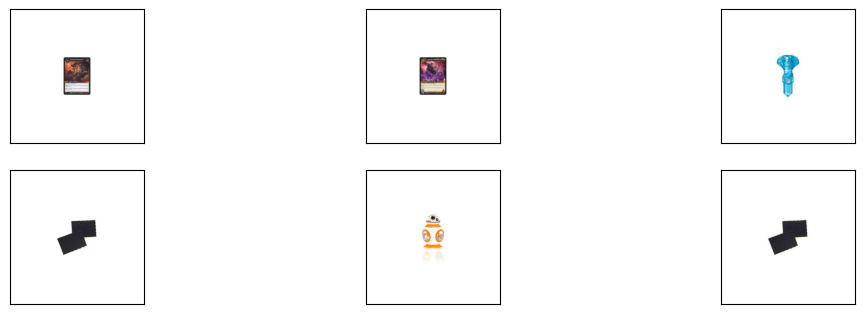

In [152]:
# hash = pHash_collisions.index[0]
hash = pHash_collisions.sample(1).index[0]
rows = df[df.image_pHash == hash]
if len(rows)>12:
    rows = rows.sample(12)
print(hash)
display_images(rows,nrow=4,ncol=3,axis=True)

#### Correlation heatmap

In [ ]:
cols = df.drop(columns='prdtypecode_str').loc[:,'mean_r':].columns.tolist()
print(cols)

['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b', 'median_r', 'median_g', 'median_b', 'mean_gray', 'std_gray', 'median_gray', 'essential_pixel_count', 'x_min', 'y_min', 'x_max', 'y_max', 'len_designation', 'len_description', 'essential_width', 'essential_height', 'essential_aspect_ratio', 'essential_area', 'rectangleness']


<Axes: >

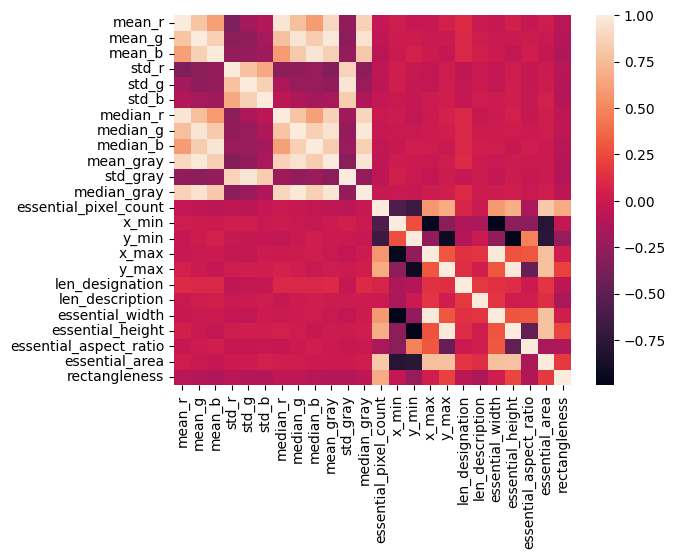

In [ ]:
sns.heatmap(df[cols].corr())

Les deux gros blocs rouges signifient que les variables décrivant les canaux des images sont peu corrélés avec les autres variables.

Les médianes et moyennes des canaux sont corrélées: Ceci suggère que pour chaque image, l'intensité moyenne de couleur tend à être similaire sur les trois canaux RGB ainsi qu'en niveaux de gris.

Les écarts-types des canaux sont corrélés entre eux mais pas avec leurs moyennes et médianes.

Ces observations laissent penser que la couleur n'est pas essentielle au jeu de données, et qu'on pourrait se contenter d'images en nuances de gris.

On remarque une anti-corrélation entre x_min et x_max, et une anti-corrélation entre y_min et y_max. Ça correspond au fait que les produits semblent centrés sur les images.

De façon non surprenante, on observe une (anti-)corrélation entre essential_width et x_\*, ainsi qu'entre essential_height et y_\* (qui correspondent à la taille et aux coordonnées du rectangle délimitant la partie non blanche).

Les variables essential_area et essential_pixel_count sont un peu corrélées, comme on pouvait s'y attendre (le rectangle délimitant la partie non blanche est corrélé au nombre de pixels non blancs).

Les longueurs de désignations et de descriptions produits ne semblent pas corrélées entre elles. Elles auraient pu être corrélées si par exemple certains vendeurs tendent à être moins concis que d'autres. Comme on pouvait s'y attendre, ces longueurs de textes ne semblent pas corrélées avec les variables décrivant les images. Ce manque de corrélation pourra donner plus de richesse aux données pour les modèles prédictifs.

On pourra envisager de retirer certaines variables hautement (anti-)corrélées pour voir si ça améliore la performance des modèles.

(La variable cible n'est pas dans ce graphique car elle est catégorielle non ordinale.)

#### Par catégorie produit

##### Désignation, description

In [ ]:
# sns.catplot(y = "prdtypecode_str", x = "len_designation", kind = "box" , data = df)

In [ ]:
# sns.catplot(y = "prdtypecode_str", x = "len_description", kind = "box" , data = df)

In [ ]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
cols=['len_designation', 'len_description']
reduced_df=df[cols]
s.fit(reduced_df)
reduced_df = s.transform(reduced_df)
reduced_df = pd.DataFrame(reduced_df,columns=cols)
reduced_df['prdtypecode'] = df['prdtypecode'].astype(str)
reduced_df.describe()

,len_designation,len_description
count,8.491600e+04,8.491600e+04
mean,-9.120679e-17,-3.146216e-17
std,1.000006e+00,1.000006e+00
min,-1.607997e+00,-6.948778e-01
25%,-7.382703e-01,-6.948778e-01
50%,-1.675122e-01,-3.888727e-01
75%,5.391408e-01,3.953480e-01
max,4.887774e+00,1.579893e+01


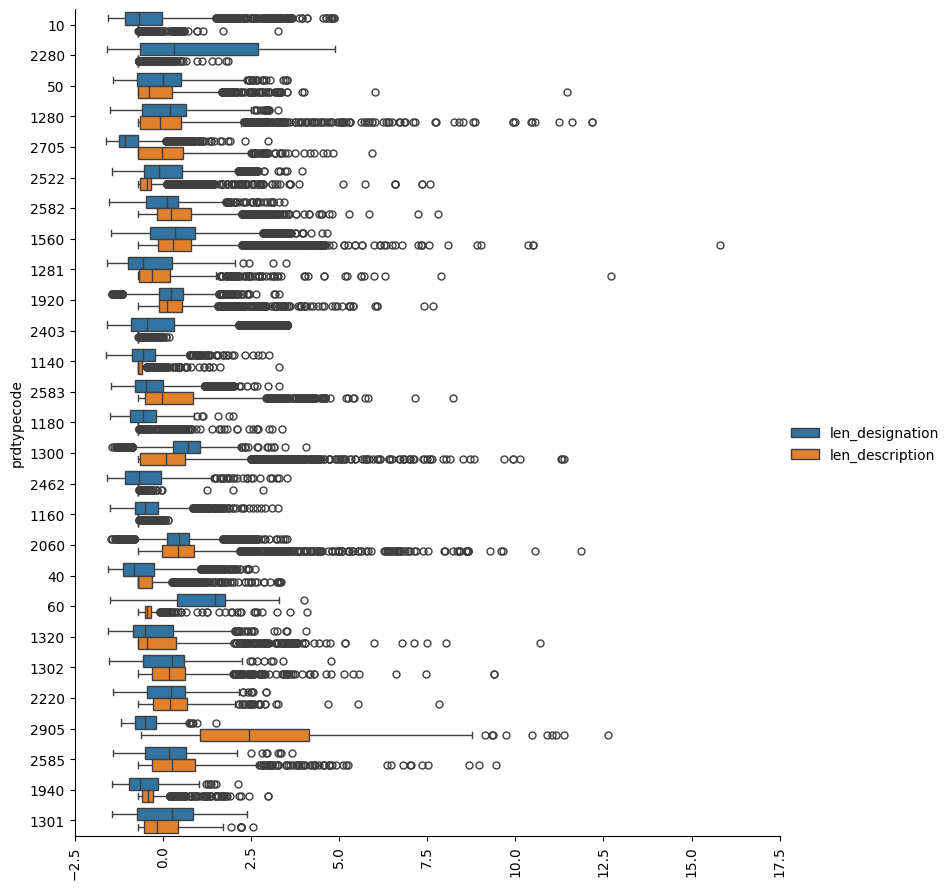

In [ ]:
df_melted = reduced_df.melt(
    id_vars=['prdtypecode'],
    value_vars=cols,
    var_name='var', # Nom de la nouvelle colonne pour les variables
    value_name='var_value' # Nom de la nouvelle colonne pour les valeurs
)
g = sns.catplot(y = "prdtypecode", x = "var_value", hue='var', kind = "box" , data = df_melted, aspect=.9, height=9) #.set(xlim=(0, 3))
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité

# enlever le label de l'axe x
g.set_axis_labels(x_var="", y_var=None)

# enlever le titre de la légende
if g.legend:
    g.legend.set_title(None)

Pour comparer sur un même graphique les longueurs de désignations et descriptions (qui ont des échelles très différentes), on les a normalisé (centré-réduit). Ces variables semblent aider à distinguer les catégories produits. On observe aussi le peu de corrélation entre ces deux variables.

##### Couleur, luminosité : moyennes

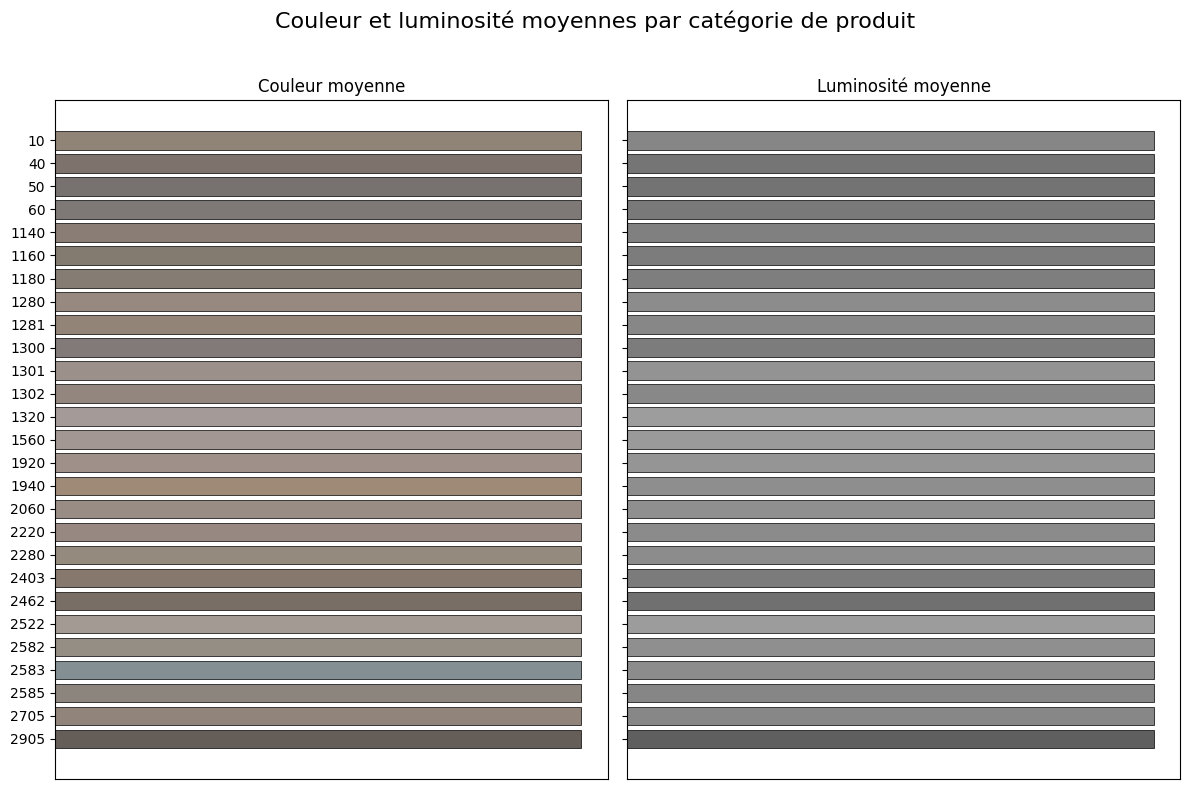

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Préparer les données ---
# Grouper une seule fois pour l'efficacité
avg_stats = df.groupby('prdtypecode')[['mean_r', 'mean_g', 'mean_b', 'mean_gray']].mean()

# Normaliser les valeurs de couleur et de gris pour l'affichage (entre 0 et 1)
avg_colors_normalized = avg_stats[['mean_r', 'mean_g', 'mean_b']] / 255.0
avg_gray_normalized = avg_stats[['mean_gray', 'mean_gray', 'mean_gray']] / 255.0 # Tripler le gris

# Obtenir les labels des catégories
category_labels = avg_stats.index.astype(str)

# --- Créer la figure et les subplots ---
# Définir une figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Couleur et luminosité moyennes par catégorie de produit", fontsize=16)

# --- Subplot 1: Couleur moyenne ---
ax1.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_colors_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax1.set_title("Couleur moyenne")
ax1.set_xticks([]) # Masquer les graduations de l'axe x
ax1.invert_yaxis() # Inverser l'axe y pour un ordre naturel

# --- Subplot 2: Luminosité moyenne ---
ax2.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_gray_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax2.set_title("Luminosité moyenne")
ax2.set_xticks([]) # Masquer les graduations de l'axe x

# Ajuster l'espacement et afficher le graphique
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour faire de la place au titre principal
plt.show()

Le graphique ci-dessus illustre la teinte globale des images à gauche, et la luminosité globale (représentée en nuances de gris) à droite. (Ces variables considèrent seulement la partie non blanche des images.)

Par exemple, la catégorie 2583 semble avoir des produits plutôt bleus.

On observe que la couleur et la luminosité moyennes des images aident à différencier les catégories de produits. On observe à nouveau la corrélation entre mean_[rgb] et mean_gray.

Ici, la couleur semble en fait utile, contrairement à ce que suggéraient la table de corrélation et les hashes des images.

In [ ]:
# Préparation des données : passer d'un format large à un format long
df_melted = df.melt(
    id_vars=['prdtypecode'],
    value_vars=['mean_r', 'mean_g', 'mean_b', 'mean_gray'],
    var_name='channel', # Nom de la nouvelle colonne pour les canaux
    value_name='mean_value' # Nom de la nouvelle colonne pour les valeurs
)
df_melted

,prdtypecode,channel,mean_value
0,10,mean_r,221.107000
1,2280,mean_r,141.165504
2,50,mean_r,160.981003
3,1280,mean_r,88.885737
4,2705,mean_r,115.419371
...,...,...,...
339659,40,mean_gray,104.778450
339660,2583,mean_gray,115.349413
339661,2280,mean_gray,160.808870
339662,1560,mean_gray,172.623062


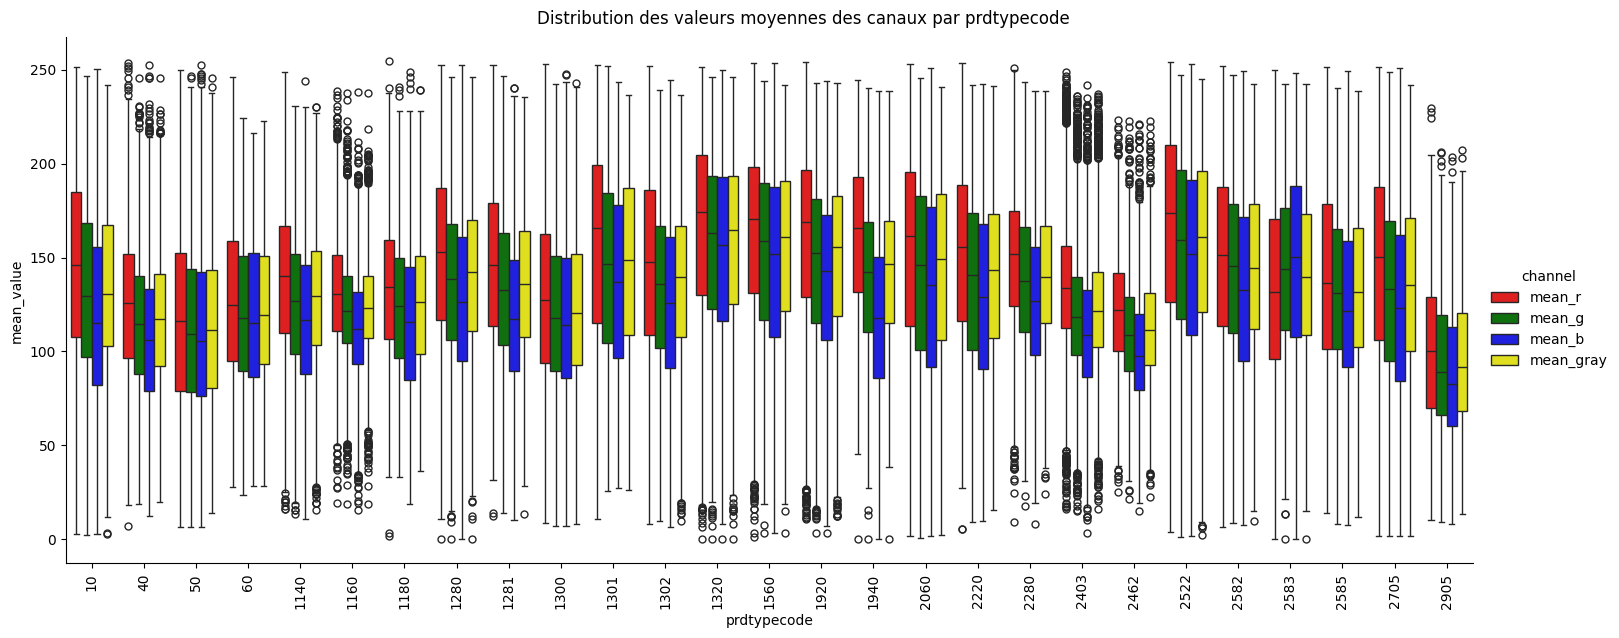

In [ ]:
# Utiliser catplot de Seaborn pour créer des boxplots pour chaque canal et chaque catégorie
g = sns.catplot(
    data=df_melted,
    x='prdtypecode',
    y='mean_value',
    hue='channel',
    kind='box',  # 'bar' ou 'violin' sont aussi de bonnes options
    height=6,
    aspect=2.5,
    palette={'mean_r': 'red', 'mean_g': 'green', 'mean_b': 'blue', 'mean_gray': 'yellow'}
)

g.fig.suptitle("Distribution des valeurs moyennes des canaux par prdtypecode", y=1.02)
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité
plt.show()

Même remarque, mais ce graphique est plus précis : la couleur et la luminosité moyenne des images aident bien à différencier les catégories de produits. On observe encore la corrélation entre mean_[rgb] et mean_gray.

##### Couleur, luminosité : médianes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             84916 non-null  object 
 1   description             55116 non-null  object 
 2   productid               84916 non-null  int64  
 3   imageid                 84916 non-null  int64  
 4   prdtypecode             84916 non-null  int64  
 5   image_hash              84916 non-null  object 
 6   gray_image_hash         84916 non-null  object 
 7   mean_r                  84916 non-null  float64
 8   mean_g                  84916 non-null  float64
 9   mean_b                  84916 non-null  float64
 10  std_r                   84916 non-null  float64
 11  std_g                   84916 non-null  float64
 12  std_b                   84916 non-null  float64
 13  median_r                84916 non-null  float64
 14  median_g                84916 non-null  flo

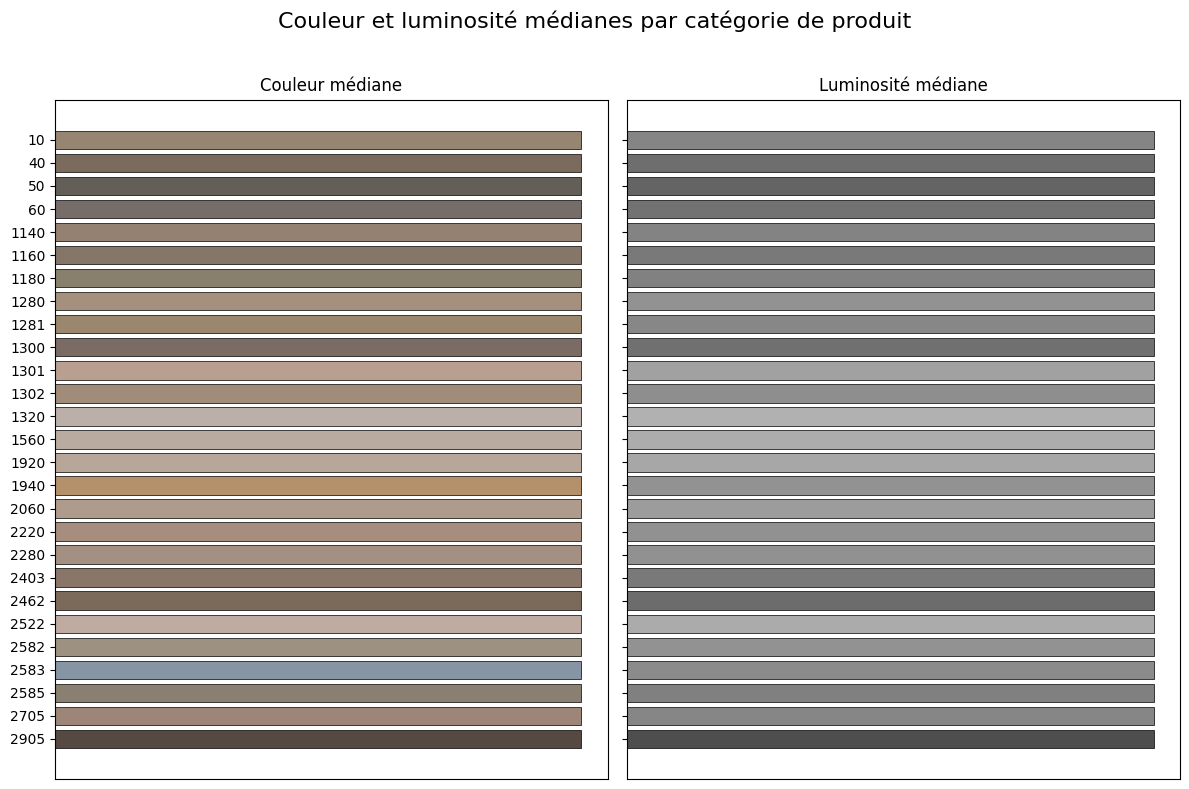

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Préparer les données ---
# Grouper une seule fois pour l'efficacité
avg_stats = df.groupby('prdtypecode')[['median_r', 'median_g', 'median_b', 'median_gray']].median()

# Normaliser les valeurs de couleur et de gris pour l'affichage (entre 0 et 1)
avg_colors_normalized = avg_stats[['median_r', 'median_g', 'median_b']] / 255.0
avg_gray_normalized = avg_stats[['median_gray', 'median_gray', 'median_gray']] / 255.0 # Tripler le gris

# Obtenir les labels des catégories
category_labels = avg_stats.index.astype(str)

# --- Créer la figure et les subplots ---
# Définir une figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Couleur et luminosité médianes par catégorie de produit", fontsize=16)

# --- Subplot 1: Couleur médiane ---
ax1.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_colors_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax1.set_title("Couleur médiane")
ax1.set_xticks([]) # Masquer les graduations de l'axe x
ax1.invert_yaxis() # Inverser l'axe y pour un ordre naturel

# --- Subplot 2: Luminosité médiane ---
ax2.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_gray_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax2.set_title("Luminosité médiane")
ax2.set_xticks([]) # Masquer les graduations de l'axe x

# Ajuster l'espacement et afficher le graphique
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour faire de la place au titre principal
plt.show()

Le graphique ci-dessus illustre la teinte globale des images à gauche, et la luminosité globale (représentée en nuances de gris) à droite. (Ces variables considèrent seulement la partie non blanche des images.)

On observe que la couleur et la luminosité moyennes des images aident à différencier les catégories de produits. On observe à nouveau la corrélation entre median_[rgb] et median_gray.

Le graphique ci-dessus des médianes est plus varié que le graphique des moyennes. Ceci suggère que les médianes des canaux sont un moyen plus puissant de distinguer les catégories produits.

In [ ]:
# Préparation des données : passer d'un format large à un format long
df_melted = df.melt(
    id_vars=['prdtypecode'],
    value_vars=['median_r', 'median_g', 'median_b', 'median_gray'],
    var_name='channel', # Nom de la nouvelle colonne pour les canaux
    value_name='median_value' # Nom de la nouvelle colonne pour les valeurs
)
df_melted

,prdtypecode,channel,median_value
0,10,median_r,241.0
1,2280,median_r,169.0
2,50,median_r,162.0
3,1280,median_r,83.0
4,2705,median_r,107.0
...,...,...,...
339659,40,median_gray,91.0
339660,2583,median_gray,125.0
339661,2280,median_gray,161.0
339662,1560,median_gray,215.0


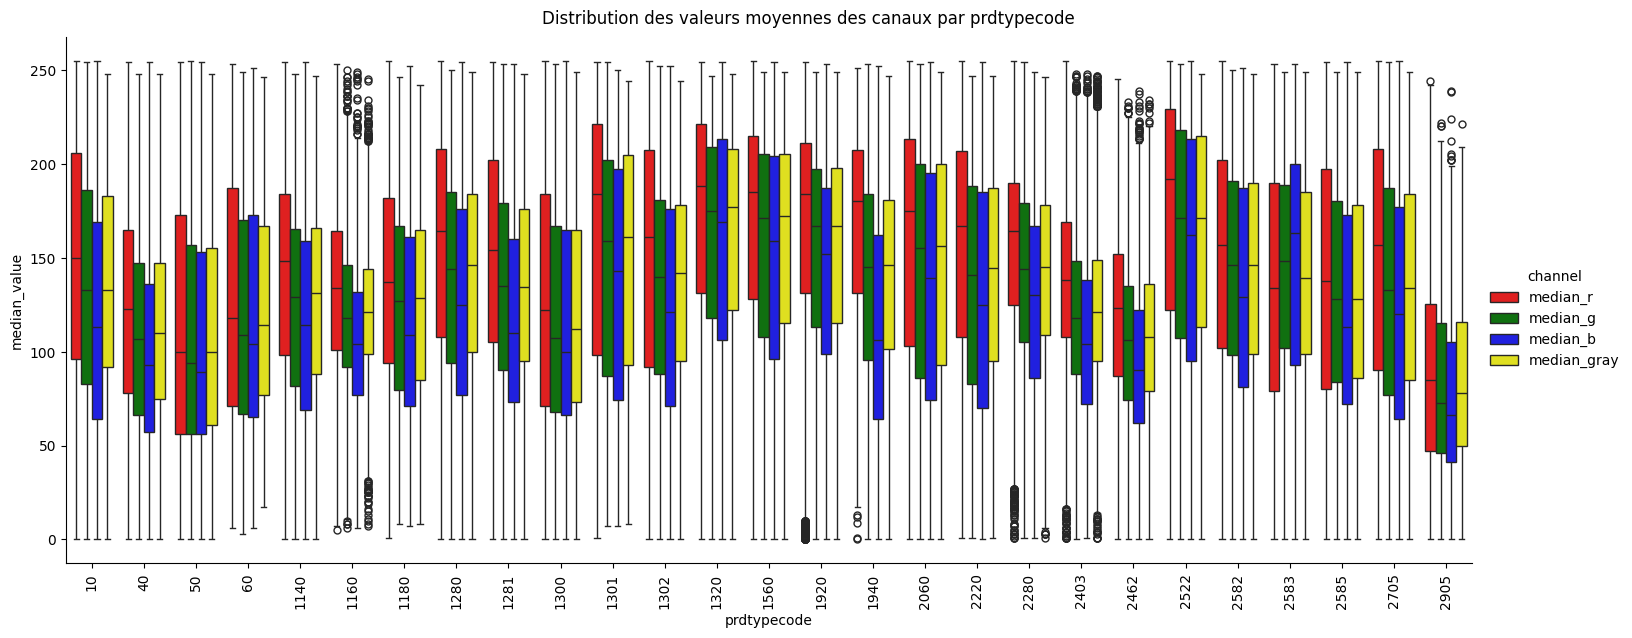

In [ ]:
# Utiliser catplot de Seaborn pour créer des boxplots pour chaque canal et chaque catégorie
g = sns.catplot(
    data=df_melted,
    x='prdtypecode',
    y='median_value',
    hue='channel',
    kind='box',  # 'bar' ou 'violin' sont aussi de bonnes options
    height=6,
    aspect=2.5,
    palette={'median_r': 'red', 'median_g': 'green', 'median_b': 'blue', 'median_gray': 'yellow'}
)

g.fig.suptitle("Distribution des valeurs moyennes des canaux par prdtypecode", y=1.02)
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité
plt.show()

Même remarque, mais ce graphique est plus précis : la couleur et la luminosité médiane des images aident bien à différencier les catégories de produits. On observe encore la corrélation entre median_[rgb] et median_gray.

##### Couleur, luminosité : écarts-types

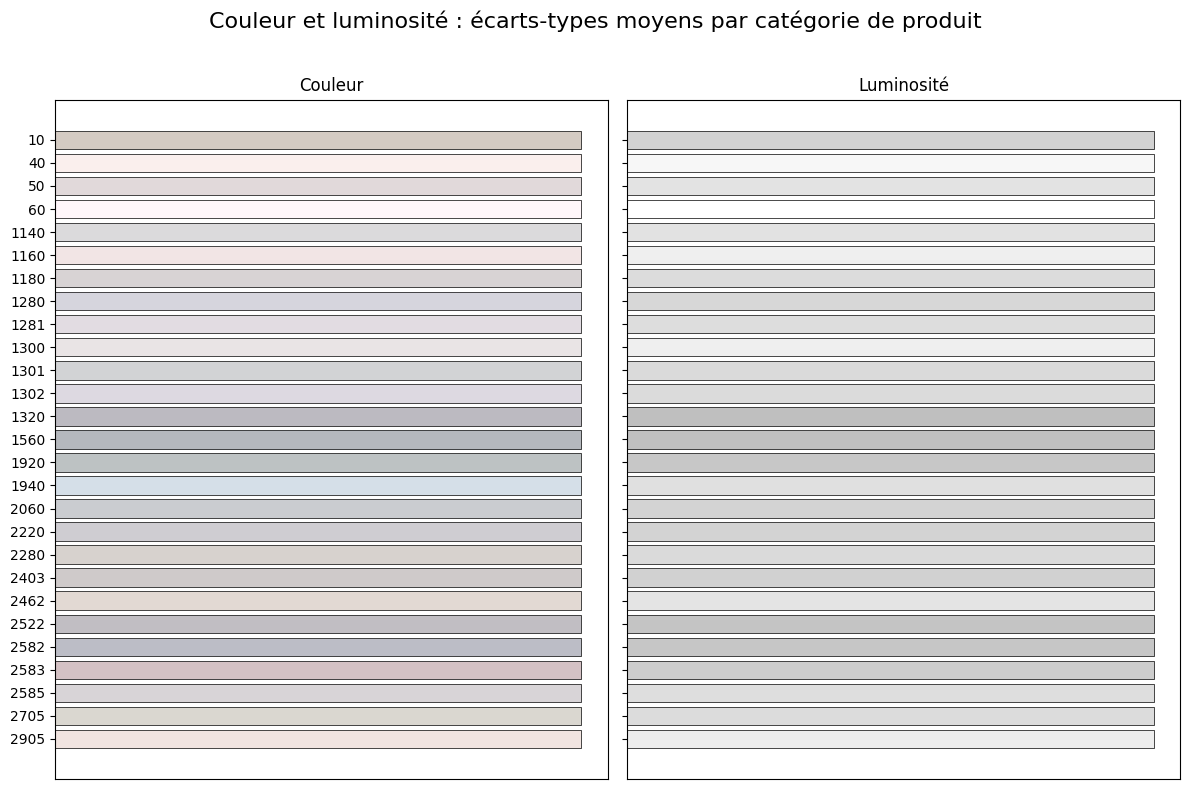

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Préparer les données ---
# Grouper une seule fois pour l'efficacité
avg_stats = df.groupby('prdtypecode')[['std_r', 'std_g', 'std_b', 'std_gray']].mean()

avg_colors_normalized = avg_stats[['std_r', 'std_g', 'std_b']]
avg_gray_normalized = avg_stats[['std_gray', 'std_gray', 'std_gray']] # Tripler le gris
# Normaliser les valeurs de couleur et de gris pour l'affichage (entre 0 et 1)
avg_colors_normalized /= avg_colors_normalized.max().max()
avg_gray_normalized /= avg_gray_normalized.max().max()

# Obtenir les labels des catégories
category_labels = avg_stats.index.astype(str)

# --- Créer la figure et les subplots ---
# Définir une figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Couleur et luminosité : écarts-types moyens par catégorie de produit", fontsize=16)

# --- Subplot 1: Couleur moyenne ---
ax1.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_colors_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax1.set_title("Couleur")
ax1.set_xticks([]) # Masquer les graduations de l'axe x
ax1.invert_yaxis() # Inverser l'axe y pour un ordre naturel

# --- Subplot 2: Luminosité moyenne ---
ax2.barh(
    y=category_labels,
    width=[1] * len(category_labels),
    color=avg_gray_normalized.values,
    edgecolor="black",
    linewidth=0.5
)
ax2.set_title("Luminosité")
ax2.set_xticks([]) # Masquer les graduations de l'axe x

# Ajuster l'espacement et afficher le graphique
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuster pour faire de la place au titre principal
plt.show()

Le graphique ci-dessus des écarts-types est plus varié que le graphique des moyennes. Ceci suggère que les écarts-types des canaux sont un moyen plus puissant de distinguer les catégories produits. En termes plus simples, le contraste des images semble bien aider à distinguer les catégories produits.

Par exemple, la catégorie 1940 semble avoir un écart-type relativement important pour le bleu, et la catégorie 2583 semble avoir un écart-type relativement important pour le rouge. Ceci est confirmé par le graphique plus précis en boîtes à moustaches plus bas.

On observe aussi ici la corrélation entre std_[rgb] et std_gray. La couleur révèle plus encore son importance pour prédire la catégorie produit, ici grâce au contraste des couleurs des produits.

(Pour clarifier le sens du graphique : on considère l'écart-type d'un canal de la partie non blanche d'une image donnée, puis on prend la moyenne de ces écarts-types d'un canal pour une catégorie produit. On combine les 3 moyennes (R,G,B) pour résumer ces écarts-types par une couleur. On procède ainsi pour chaque catégorie produit. L'approche est similaire pour la luminosité.)

In [ ]:
# Préparation des données : passer d'un format large à un format long
df_melted = df.melt(
    id_vars=['prdtypecode'],
    value_vars=['std_r', 'std_g', 'std_b', 'std_gray'],
    var_name='channel', # Nom de la nouvelle colonne pour les canaux
    value_name='std_value' # Nom de la nouvelle colonne pour les valeurs
)

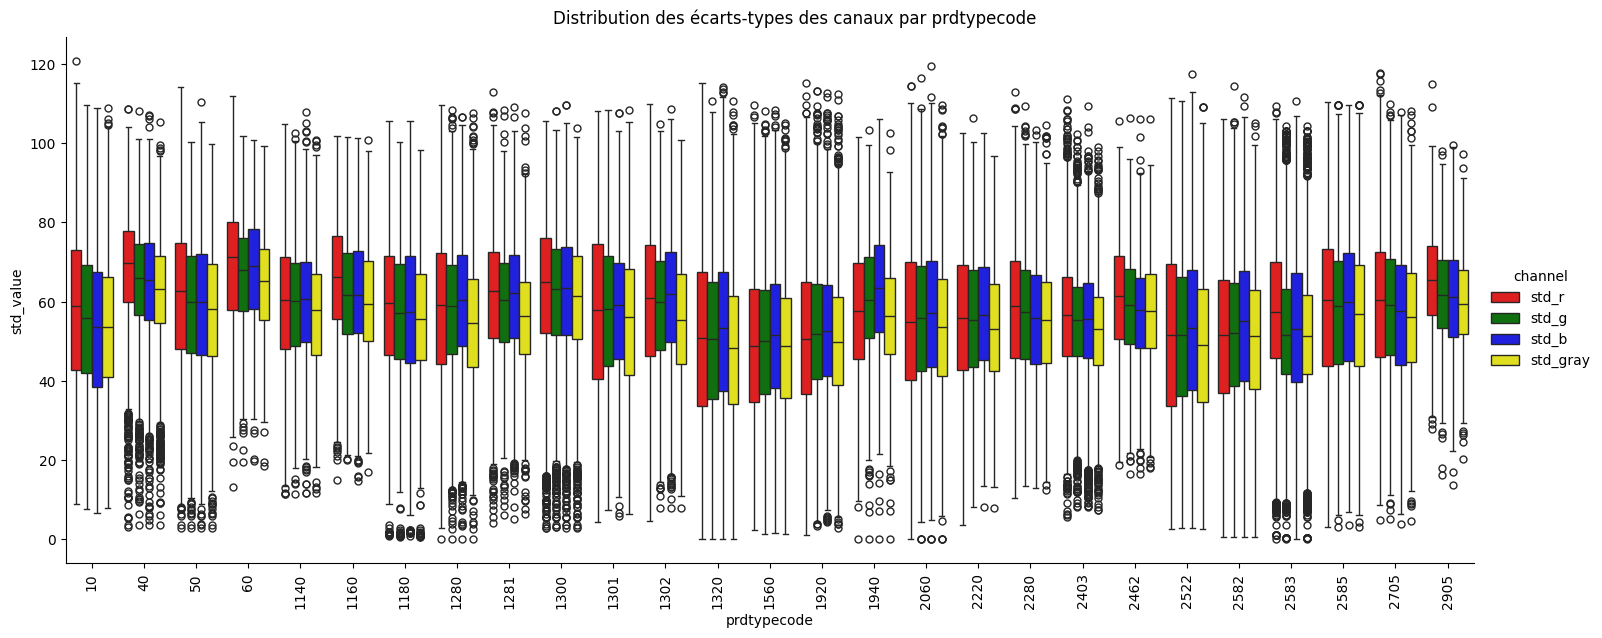

In [ ]:
# Utiliser catplot de Seaborn pour créer des boxplots pour chaque canal et chaque catégorie
g = sns.catplot(
    data=df_melted,
    x='prdtypecode',
    y='std_value',
    hue='channel',
    kind='box',  # 'bar' ou 'violin' sont aussi de bonnes options
    height=6,
    aspect=2.5,
    palette={'std_r': 'red', 'std_g': 'green', 'std_b': 'blue', 'std_gray': 'yellow'}
)

g.fig.suptitle("Distribution des écarts-types des canaux par prdtypecode", y=1.02)
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité
plt.show()

On observe à nouveau la corrélation entre std_[rgb] et std_gray.
On voit à nouveau que les écarts-types des canaux semblent aider à distinguer les catégories produits.

##### Coordonnées

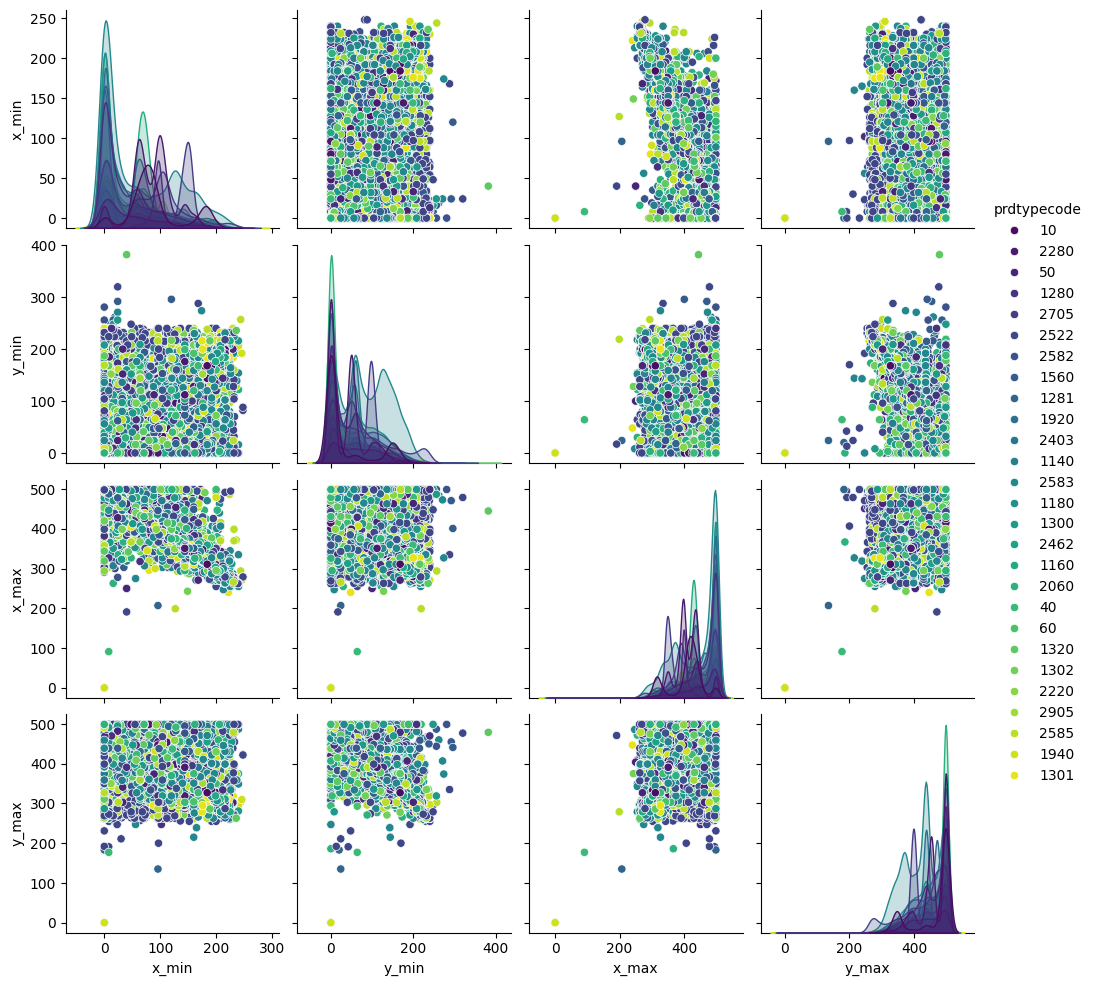

In [ ]:
# Dure 35s.
colnames = df.loc[:,'x_min':'y_max'].columns.tolist() + ['prdtypecode']

df_for_plot = df[colnames].copy()

df_for_plot['prdtypecode'] = df_for_plot['prdtypecode'].astype(str)

sns.pairplot(data=df_for_plot, hue='prdtypecode', palette='viridis') # 'viridis' est une palette qui gère bien de nombreuses catégories
plt.show()

Ci-dessus, les graphiques diagonaux indiquent que ces variables semblent bien aider à distinguer la catégorie produit. C'est peu étonnant car on peut s'attendre à ce que des produits similaires occupent la même partie de l'image.

Les graphiques non diagonaux ne montrent pas clairement de relation entre ces couples de variables et la catégorie produit. Ceci dit, on observe parfois un groupement jaune, suggérant que pour la catégorie 1301, il pourrait y avoir un couplage intéressant entre ces variables. 

In [ ]:
# df['prdtypecode_str'] = df['prdtypecode'].astype(str)
# df_melted = df.melt(
#     id_vars=['prdtypecode_str'],
#     value_vars=['x_min', 'y_min'], # , 'x_max', 'y_max'
#     var_name='coord', # Nom de la nouvelle colonne pour les variables
#     value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
# )
# g = sns.catplot(y = "prdtypecode_str", x = "coord_value", hue='coord', kind = "box" , data = df_melted, aspect=1) #.set(xlim=(0, 3))
# g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité


In [ ]:
# df['prdtypecode_str'] = df['prdtypecode'].astype(str)
# df_melted = df.melt(
#     id_vars=['prdtypecode_str'],
#     value_vars=['x_max', 'y_max'],
#     var_name='coord', # Nom de la nouvelle colonne pour les variables
#     value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
# )
# g = sns.catplot(y = "prdtypecode_str", x = "coord_value", hue='coord', kind = "box" , data = df_melted, aspect=1) #.set(xlim=(0, 3))
# g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité

Pour comparer sur un même graphique la relation entre la catégorie produit et les 4 coordonnées, une standardisation des coordonnées est bienvenue.

In [ ]:
cols=['x_min', 'y_min', 'x_max', 'y_max']
coords = df[cols]
coords.describe()

,x_min,y_min,x_max,y_max
count,84916.000000,84916.000000,84916.000000,84916.000000
mean,55.918555,55.781254,442.835732,446.159605
std,56.063024,55.990220,56.561352,54.738523
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,400.750000,407.000000
50%,48.000000,48.000000,454.000000,456.000000
75%,96.000000,96.000000,499.000000,499.000000
max,248.000000,382.000000,499.000000,499.000000


On va utiliser leurs versions centrées-réduites.

In [ ]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
s.fit(coords)
coords = s.transform(coords)
coords = pd.DataFrame(coords,columns=cols)
coords['prdtypecode'] = df['prdtypecode'].astype(str)
coords.describe()

,x_min,y_min,x_max,y_max
count,8.491600e+04,8.491600e+04,8.491600e+04,8.491600e+04
mean,2.953761e-17,-5.949360e-17,-3.396407e-16,-2.255904e-16
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-9.974290e-01,-9.962737e-01,-7.829345e+00,-8.150791e+00
25%,-9.974290e-01,-9.962737e-01,-7.440766e-01,-7.153981e-01
50%,-1.412446e-01,-1.389761e-01,1.973845e-01,1.797720e-01
75%,7.149397e-01,7.183216e-01,9.929854e-01,9.653294e-01
max,3.426190e+00,5.826387e+00,9.929854e-01,9.653294e-01


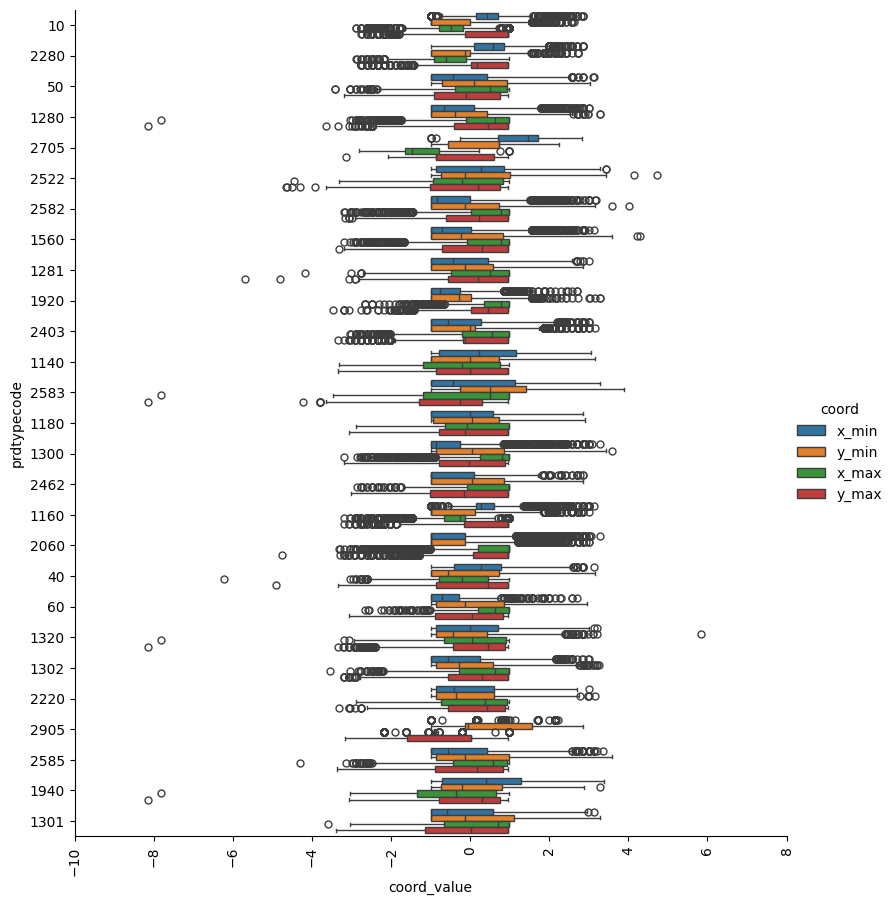

In [ ]:
df_melted = coords.melt(
    id_vars=['prdtypecode'],
    value_vars=cols,
    var_name='coord', # Nom de la nouvelle colonne pour les variables
    value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
)
g = sns.catplot(y = "prdtypecode", x = "coord_value", hue='coord', kind = "box" , data = df_melted, aspect=.9, height=9) #.set(xlim=(0, 3))
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité


Pour lire le graphique ci-dessus, il est plus facile de se concentrer sur une seule couleur à la fois.

Les coordonnées du rectangle délimitant la partie non blanche semblent aider à distinguer les catégories. Ceci correspond à l'impression que l'on a en regardant des images du jeu de données.

Sur la catégorie 10 (et quelques autres), on remarque l'anti-corrélation entre x_min et x_max, et l'anti-corrélation entre y_min et y_max (qui correspond au fait que les images semblent centrées).

##### Essential pixel count

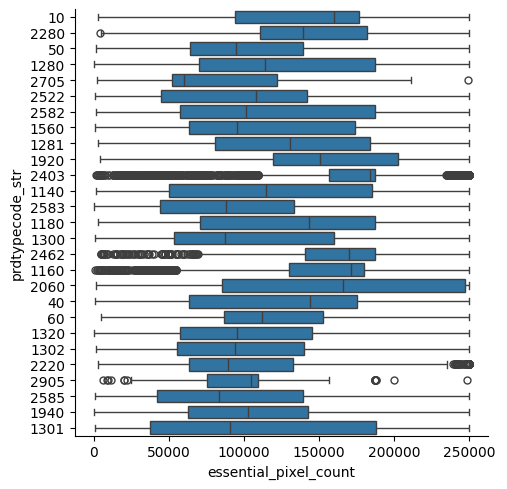

In [ ]:
sns.catplot(y = "prdtypecode_str", x = "essential_pixel_count", kind = "box" , data = df)

Le nombre de pixels non blancs sur l'image du produit semble pertinent pour distinguer les catégories. Par exemple, on peut s'attendre à ce qu'un balai (dont le manche est relativement fin) occupe moins de pixels qu'un matelas.

##### Essential dimensions

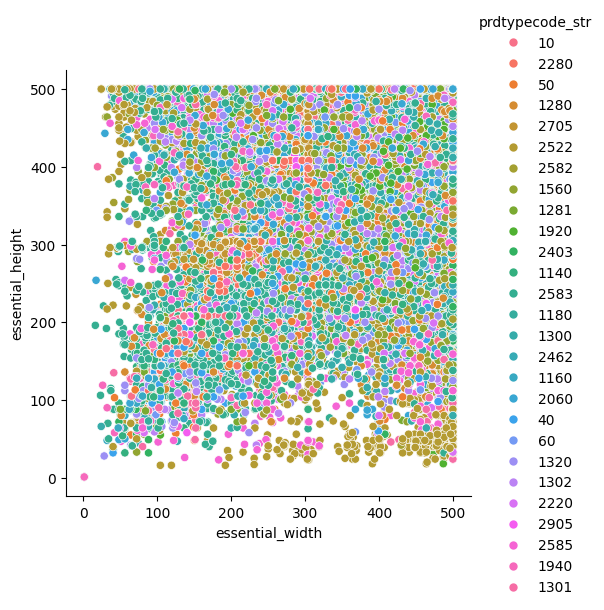

In [ ]:
sns.relplot(data=df,y='essential_height',x='essential_width',hue='prdtypecode_str')

On remarque un groupement jaune en bas à droite, suggérant qu'une catégorie jaune a certains produits en un format paysage plus étiré que les autres catégories.

On regarde le ratio d'aspect plus précisément un peu plus tard.

In [ ]:
# sns.catplot(x = "essential_width", y = "prdtypecode_str", kind = "box" , data = df)

In [ ]:
# sns.catplot(x = "essential_height", y = "prdtypecode_str", kind = "box" , data = df)

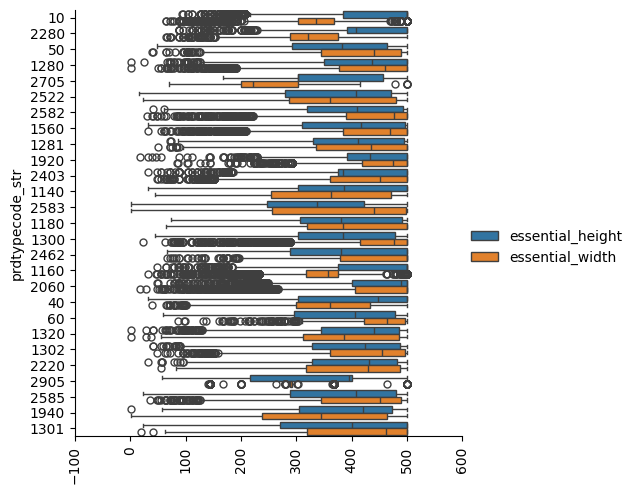

In [ ]:
df_melted = df.melt(
    id_vars=['prdtypecode_str'],
    value_vars=['essential_height', 'essential_width'],
    var_name='coord', # Nom de la nouvelle colonne pour les variables
    value_name='coord_value' # Nom de la nouvelle colonne pour les valeurs
)
g = sns.catplot(y = "prdtypecode_str", x = "coord_value", hue='coord', kind = "box" , data = df_melted) #, aspect=.9, height=9) #.set(xlim=(0, 3))
g.set_xticklabels(rotation=90) # Pivoter les labels pour une meilleure lisibilité

# enlever le label de l'axe x
g.set_axis_labels(x_var="", y_var=None)

# enlever le titre de la légende
if g.legend:
    g.legend.set_title(None)

Les dimensions du rectangle délimitant la partie non blanche sur l'image du produit semblent pertinentes pour distinguer les catégories. On peut en effet s'attendre par exemple à ce qu'un balai (dont le manche est relativement fin) tienne dans un rectangle plus fin qu'un matelas. Le graphique illustre aussi la basse corrélation entre largeur et hauteur de la partie non blanche.

##### Essential aspect ratio

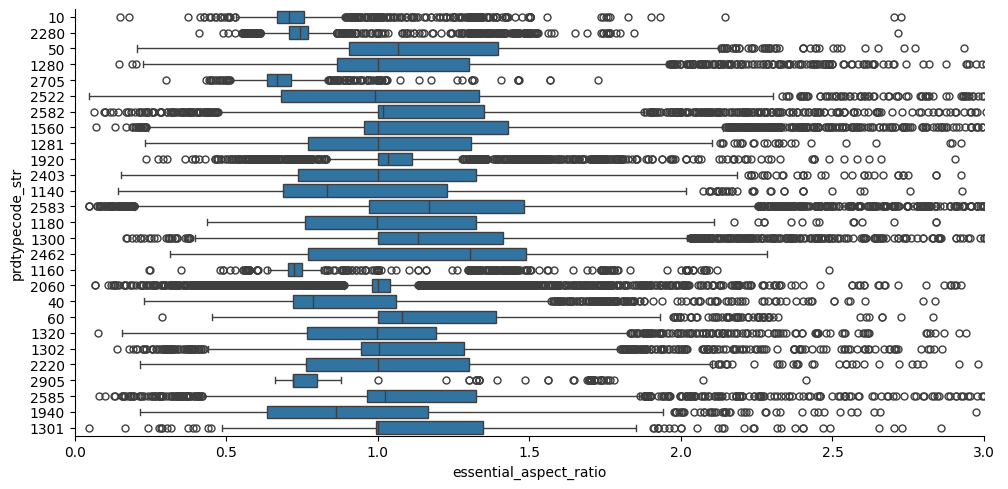

In [ ]:
sns.catplot(x = "essential_aspect_ratio", y = "prdtypecode_str", kind = "box" , data = df,aspect=2).set(xlim=(0, 3))

La variable mesure à quel point la partie non blanche de l'image est en format paysage (droite du graphique) plutôt que portrait (gauche du graphique).

On distingue à nouveau des différences de distribution entre les catégories. Par exemple, la catégorie 10 semble préférer le format portrait plus que la majorité des catégories.

(Le graphique est tronqué à 3 sur l'axe horizontal pour améliorer la lisibilité, mais il y a des outliers avec un essential_aspect_ratio de plus de 25.)

##### Essential area

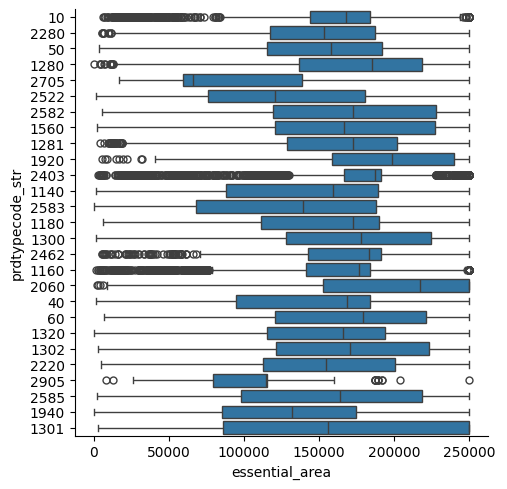

In [ ]:
sns.catplot(x = "essential_area", y = "prdtypecode_str", kind = "box" , data = df, aspect=1) #.set(xlim=(0, 3))

L'aire du rectangle délimitant la partie non blanche de l'image semble aider à distinguer les catégories.

##### Essential area and pixel count

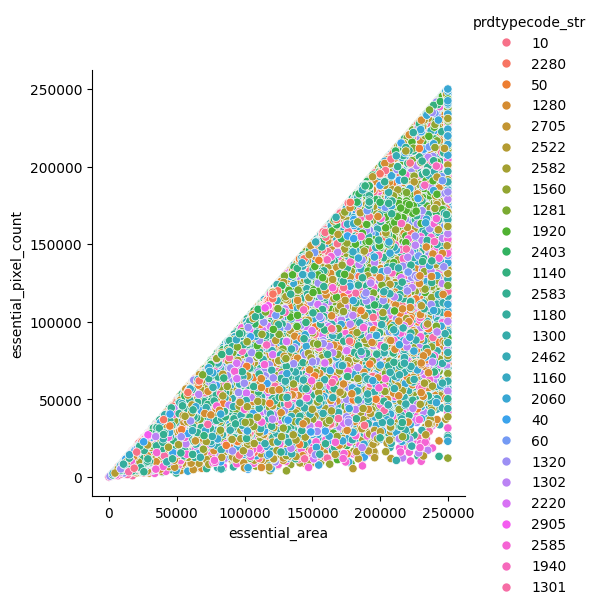

In [ ]:
sns.relplot(data=df,y='essential_pixel_count',x='essential_area',hue='prdtypecode_str')

Par construction, essential_pixel_count (nombre de pixels non blancs) est inférieur à essential_area (aire du rectangle délimitant les pixels non blancs), d'où l'apparence triangulaire. On ne remarque pas de groupement par catégorie.

##### Essential area and aspect ratio

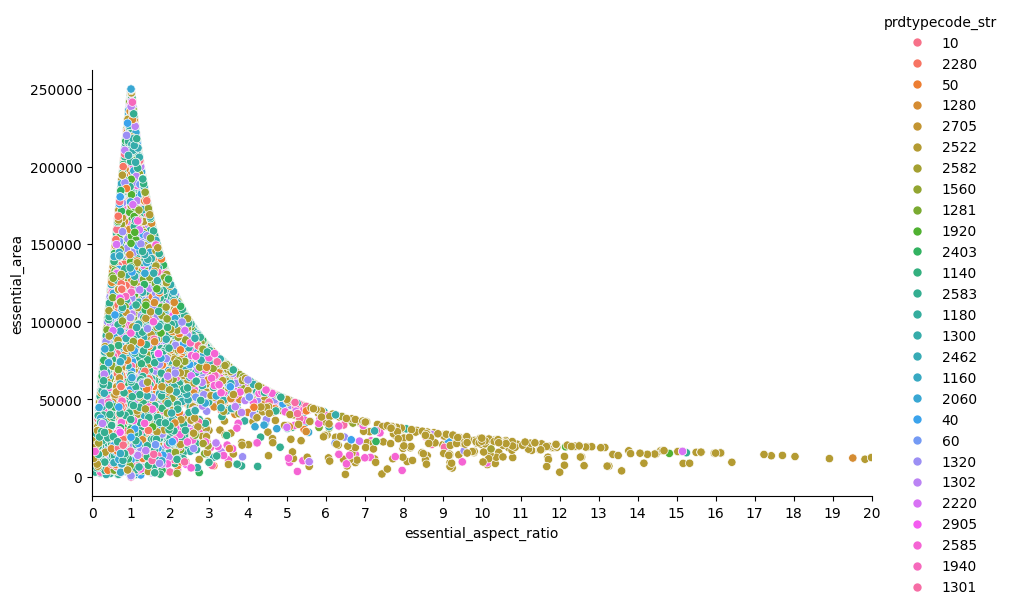

In [ ]:
g = sns.relplot(data=df.loc[:],y='essential_area',x='essential_aspect_ratio',hue='prdtypecode_str',aspect=1.8)

g.set(xlim=(0, 20))

# Get x-axis range
xmin, xmax = g.ax.get_xlim()

# Set ticks separated by 1
g.ax.set_xticks(np.arange(np.floor(xmin), np.ceil(xmax) + 1, 1))
plt.show()

L'allure de courbe lisse délimitant les points par en haut exprime une contrainte géométrique : un ratio d'aspect proche de 1 maximise l'aire d'un rectangle de périmètre fixé. Autrement dit, un carré a une aire plus grande qu'un rectangle fin de même périmètre.

On remarque un groupe jaune en bas vers le milieu du graphique, avec un ratio d'aspect d'environ 10. Mais le fait que l'aire essentielle de ce groupe soit basse semble juste dû au fait qu'ils ont un grand ratio d'aspect (vu la contrainte géométrique mentionnée précédemment), plutôt que révéler un couplage entre ces variables spécifique à cette catégorie.

##### Rectangleness

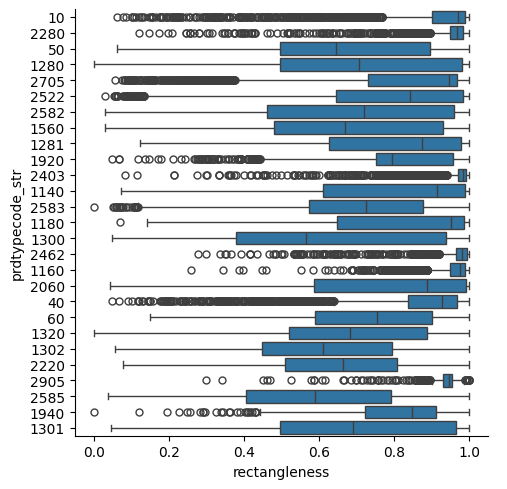

In [ ]:
sns.catplot(x = "rectangleness", y = "prdtypecode_str", kind = "box" , data = df, aspect=1) #.set(xlim=(0, 3))

Cette variable mesure à quel point la partie non blanche remplit son rectangle délimitant.

Elle semble aider à distinguer les catégories.